In [1]:
import pickle
from DataParsing import CGT
import matplotlib.pylab as plt

## Check Running Simulations

Keep running
Keep running
Keep running
Keep running
Keep running


Text(0, 0.5, 'Rg')

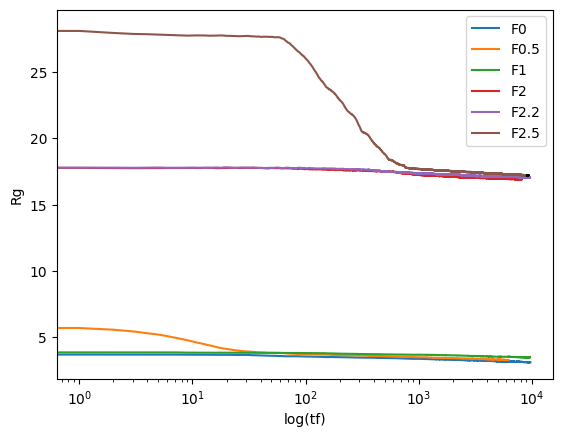

In [76]:
import numpy as np
from scipy.integrate import simpson
from scipy import stats

def RgParse(path):
    Nlpf = 101
    D = np.loadtxt(path)
    Nf = D.shape[0]//101
    D = D.reshape(Nf,Nlpf,2)
    
    #Get timeframe from first row
    t = D[:,0,0]/1e5
    #Get Rg from second column
    Rg = D[:,1:,1]
    return t,Rg

def findEquil(t, Rg):
        cutoff = 0.05

        #Compute autocorrelation
        dRg = Rg - Rg.mean()
        result = np.correlate(dRg, dRg, mode = 'full')
        result = result[result.size // 2:] # Keep the positive lags
        acf = result / result[0] #Normalized autocorrelation
        
        #Apply numerical integration
        positive_acf = acf[acf > 0]  # Ignore negative part to avoid integration errors
        tau_c = simpson(positive_acf, dx=1) #Correlation time
        t_scaled = t/tau_c
        
        for i in range(len(t)-int(tau_c)):
            res = stats.linregress(t_scaled[i:], Rg[i:])
            if res.pvalue >= cutoff:
                return i
        
        print('Keep running')
        return len(t)

path = [
    '../block1/T0.1/force0/p3/sv.rc2.5N100T0.1p1',
    '../block1/T0.1/force0.5/p3/sv.rc2.5N100T0.1p1',
    '../block1/T0.1/force1/p7/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/force2/p4/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/force2.2/p4/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/force2.5/sv.rc2.5N100T0.1p1',
    ]

f = [0, 0.5, 1, 2, 2.2, 2.5]

for i in range(len(path)):
    t, Rg = RgParse(path[i])
    t = t-t[0]
    Rg = Rg.mean(axis = 1)
    eqT = findEquil(t, Rg)
    plt.plot(t, Rg, label = f'F{f[i]}')
    plt.plot(t[eqT:], Rg[eqT:], color = 'black')

plt.legend()
plt.xscale('log')
plt.xlabel('log(tf)')
plt.ylabel('Rg')

## Block 1

#### Unloading

No equilirbium found: F0.0
No equilirbium found: F0.0
No equilirbium found: F1.0


ValueError: cannot reshape array of size 87660000 into shape (973,10000,9)

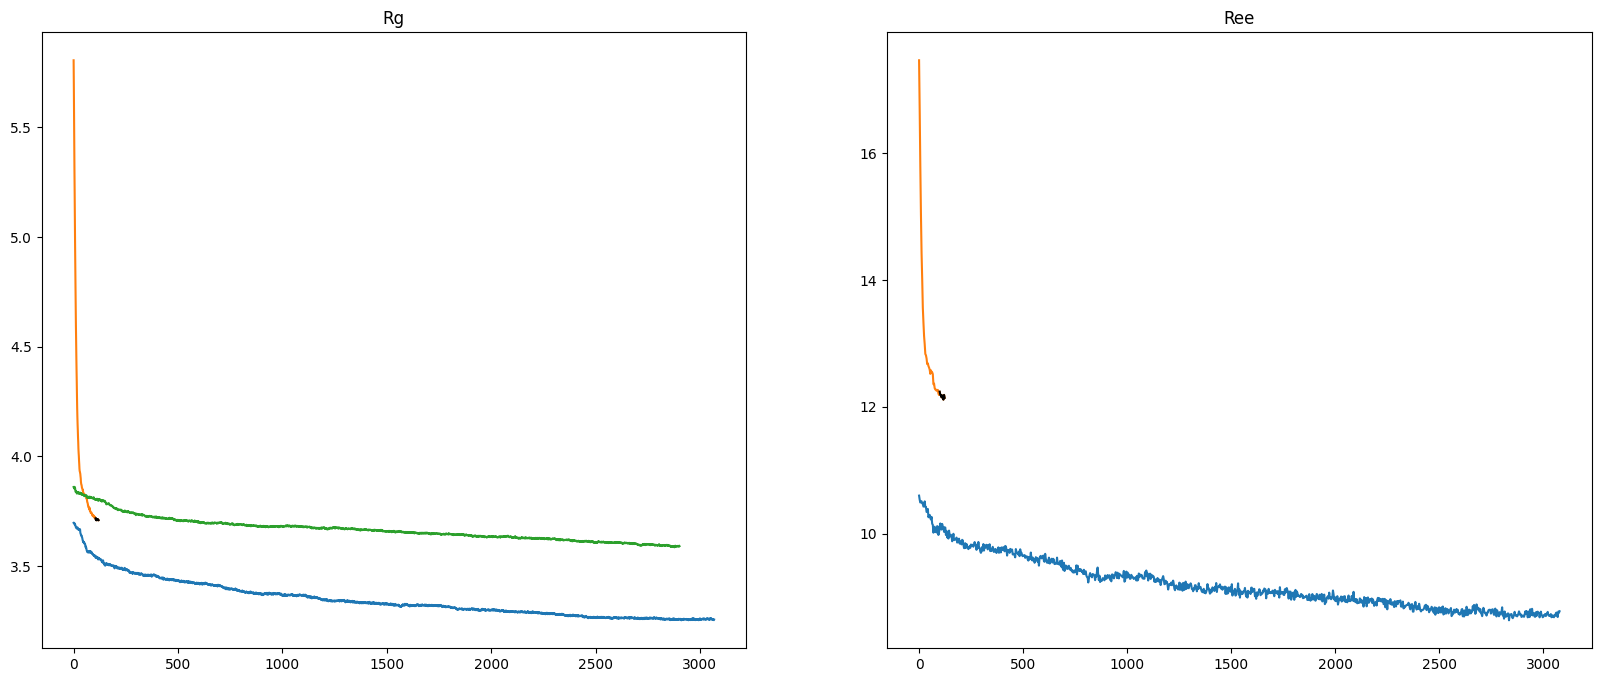

In [11]:
#T = 0.1
f = [0, 0.5, 1, 1.5, 2, 5]
t = 0.1
Rgpaths = [
    '../block1/T0.1/force0/p3/sv.rc2.5N100T0.1p1',
    '../block1/T0.1/force0.5/p3/sv.rc2.5N100T0.1p1',
    '../block1/T0.1/force1/p7/sv.rc2.5N100T0.1p1',
    '../block1/T0.1/force1.5/sv.rc2.5N100T0.1p1',
    '../block1/T0.1/force2/sv.rc2.5N100T0.1p1',
    '../block1/T0.1/force5/sv.rc2.5N100T0.1p1',
]

Reepaths = [
    '../block1/T0.1/force0/p3/dump.rc2.5N100Tp1',
    '../block1/T0.1/force0.5/p3/dump.rc2.5N100Tp1',
    '../block1/T0.1/force1/p7/dump.rc2.5N100Tp1',
    '../block1/T0.1/force1.5/dump.rc2.5N100Tp1',
    '../block1/T0.1/force2/dump.rc2.5N100Tp1',
    '../block1/T0.1/force5/dump.rc2.5N100Tp1',
]

CGT01 = CGT(f, t, 1, Reepaths, Rgpaths)

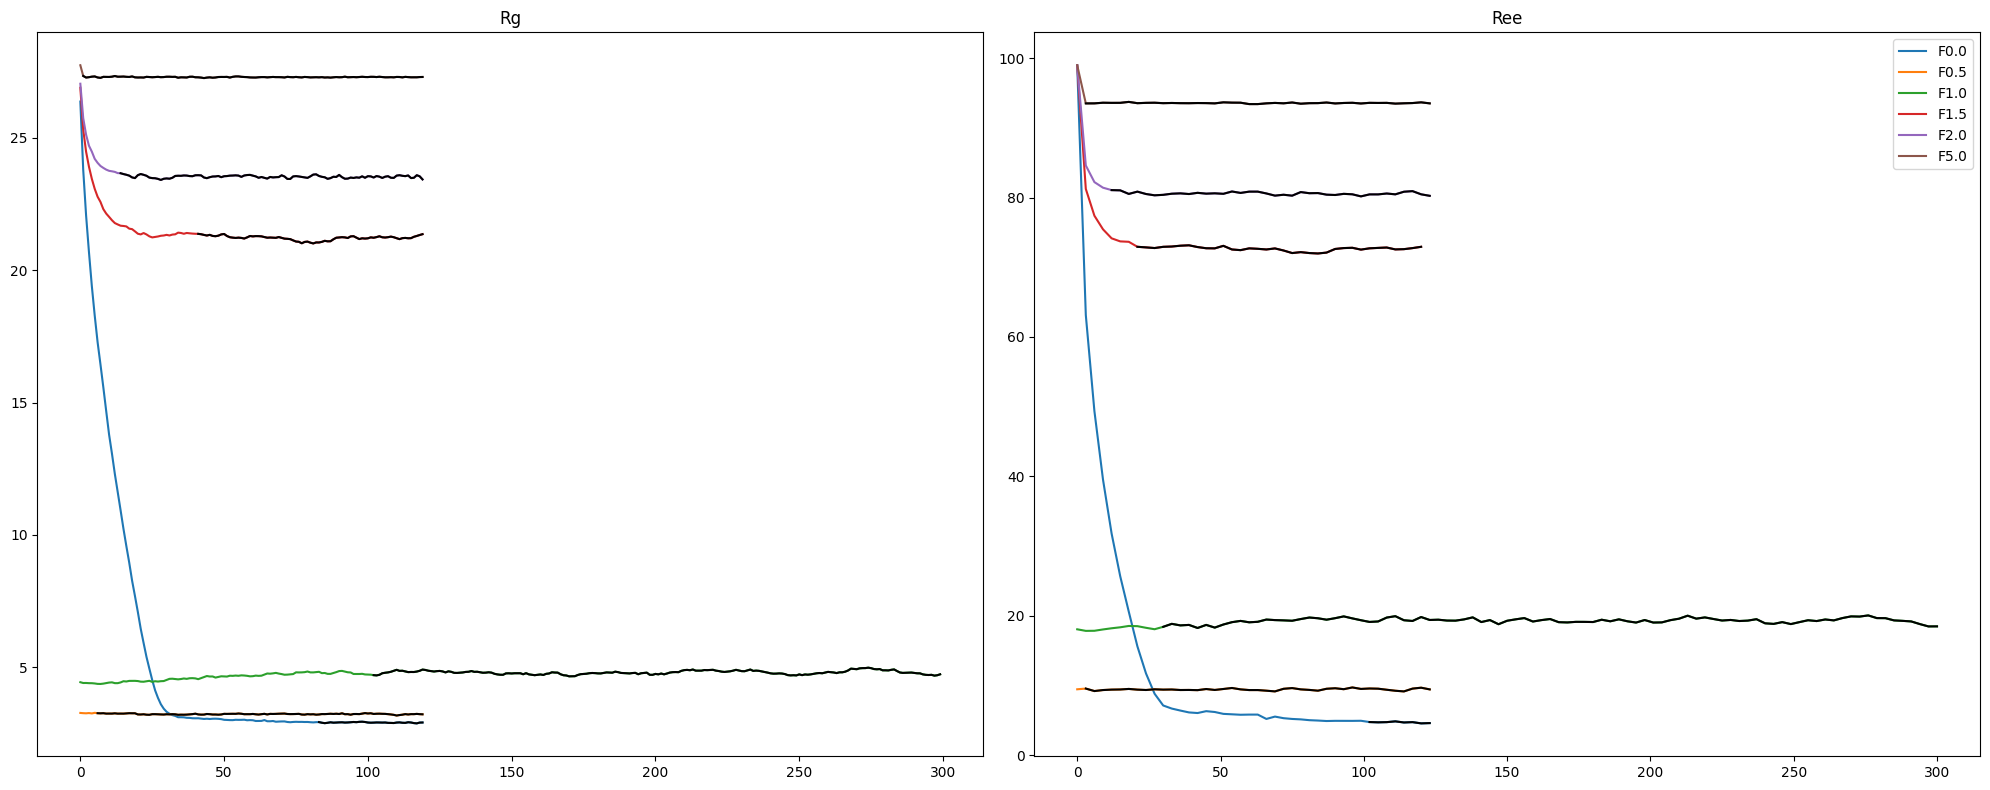

In [371]:
#T = 0.3
f = [0, 0.5, 1, 1.5, 2, 5]
t = 0.3
Rgpaths = [
    '../block1/T0.3/force0/sv.rc2.5N100T0.3p1',
    '../block1/T0.3/force0.5/p3/sv.rc2.5N100T0.3p1',
    '../block1/T0.3/force1/p7/sv.rc2.5N100T0.3p1',
    '../block1/T0.3/force1.5/sv.rc2.5N100T0.3p1',
    '../block1/T0.3/force2/sv.rc2.5N100T0.3p1',
    '../block1/T0.3/force5/sv.rc2.5N100T0.3p1',
]
Reepaths = [
    '../block1/T0.3/force0/dump.rc2.5N100Tp1',
    '../block1/T0.3/force0.5/p3/dump.rc2.5N100Tp1',
    '../block1/T0.3/force1/p7/dump.rc2.5N100Tp1',
    '../block1/T0.3/force1.5/dump.rc2.5N100Tp1',
    '../block1/T0.3/force2/dump.rc2.5N100Tp1',
    '../block1/T0.3/force5/dump.rc2.5N100Tp1',
]

CGT03 = CGT(f, t, 1, Reepaths, Rgpaths)

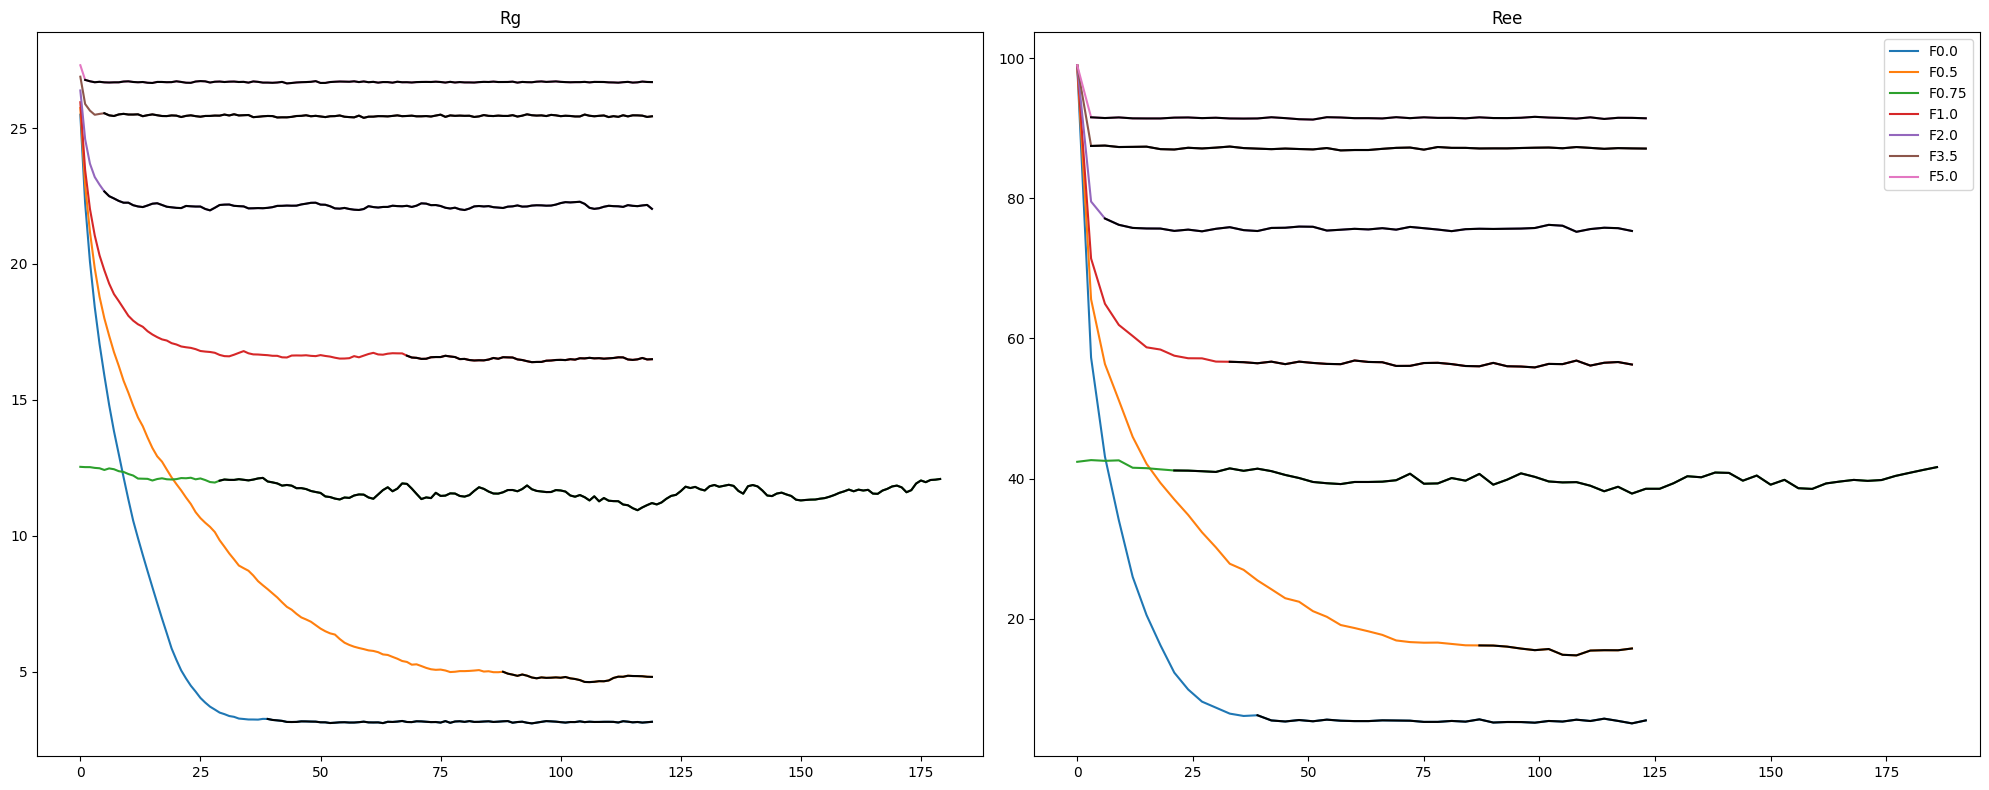

In [402]:
#T = 0.4
f = [0, 0.5, 0.75, 1, 2, 3.5, 5]
t = 0.4

Rgpaths = [
    '../block1/T0.4/force0/sv.rc2.5N100T0.4p1',
    '../block1/T0.4/force0.5/sv.rc2.5N100T0.4p1',
    '../block1/T0.4/force0.75/p2/sv.rc2.5N100T0.4p1',
    '../block1/T0.4/force1/sv.rc2.5N100T0.4p1',
    '../block1/T0.4/force2/sv.rc2.5N100T0.4p1',
    '../block1/T0.4/force3.5/sv.rc2.5N100T0.4p1',
    '../block1/T0.4/force5/sv.rc2.5N100T0.4p1',
]

Reepaths = [
    '../block1/T0.4/force0/dump.rc2.5N100Tp1',
    '../block1/T0.4/force0.5/dump.rc2.5N100Tp1',
    '../block1/T0.4/force0.75/p2/dump.rc2.5N100Tp1',
    '../block1/T0.4/force1/dump.rc2.5N100Tp1',
    '../block1/T0.4/force2/dump.rc2.5N100Tp1',
    '../block1/T0.4/force3.5/dump.rc2.5N100Tp1',
    '../block1/T0.4/force5/dump.rc2.5N100Tp1',
]

CGT04 = CGT(f, t, 1, Reepaths, Rgpaths)

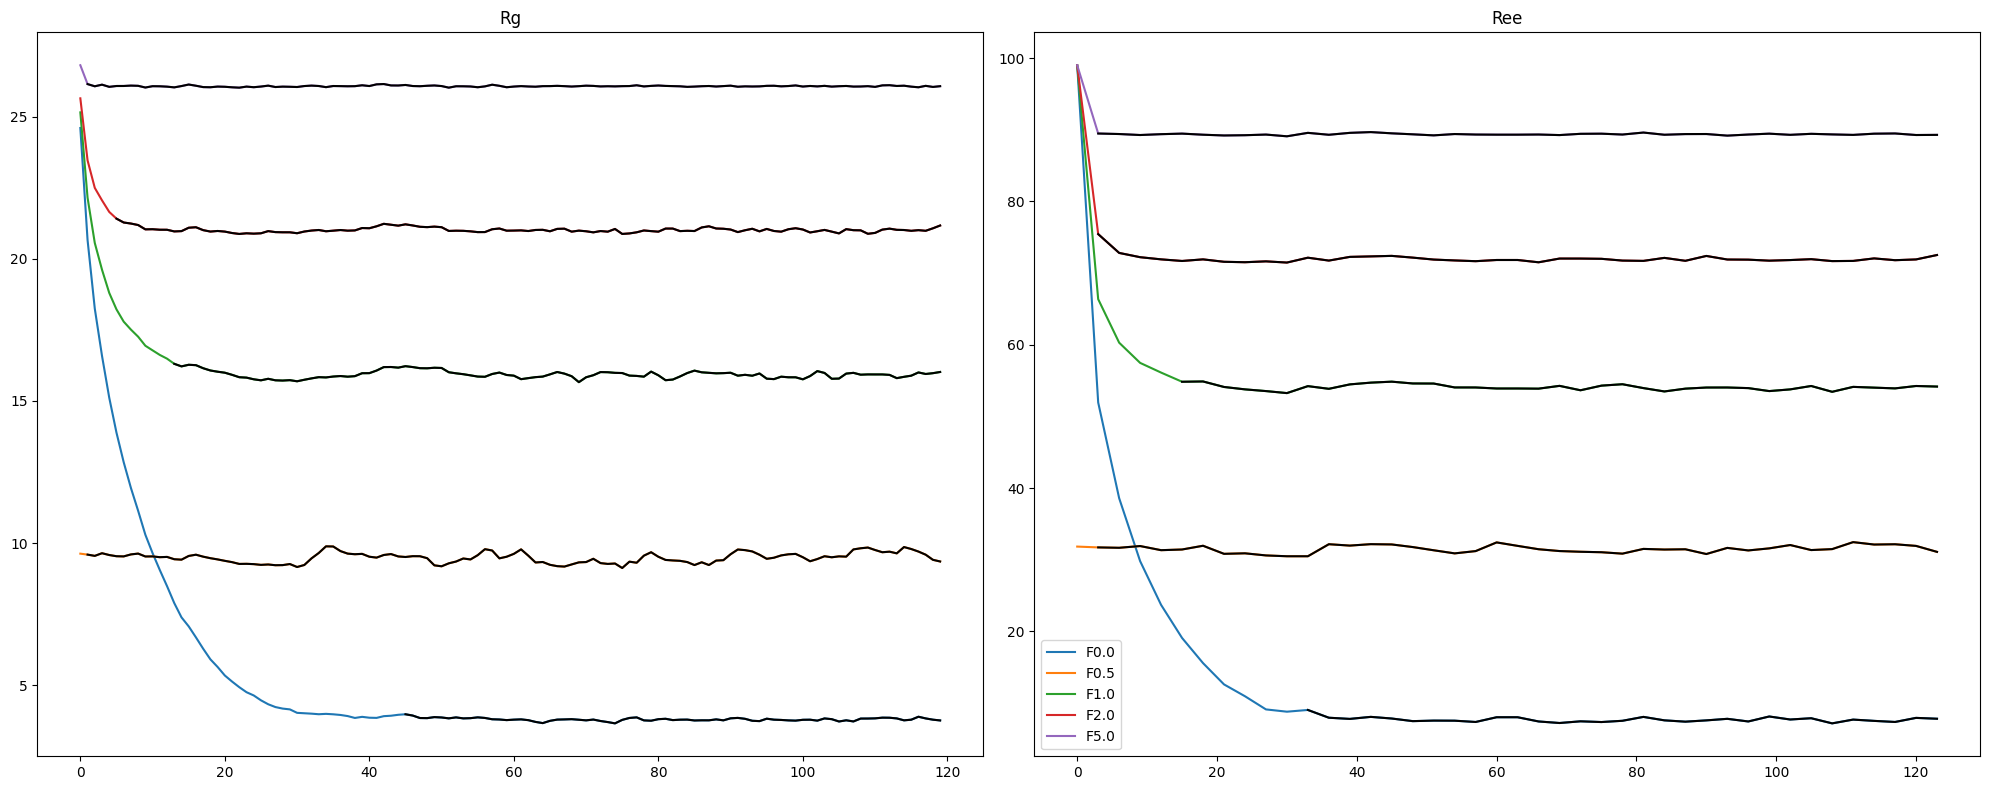

In [411]:
#T = 0.5
f = [0, 0.5, 1, 2, 5]
t = 0.5
Rgpaths = [
    '../block1/T0.5/force0/sv.rc2.5N100T0.5p1',
    '../block1/T0.5/force0.5/p2/sv.rc2.5N100T0.5p1',
    '../block1/T0.5/force1/sv.rc2.5N100T0.5p1',
    '../block1/T0.5/force2/sv.rc2.5N100T0.5p1',
    '../block1/T0.5/force5/sv.rc2.5N100T0.5p1',
]
Reepaths = [
    '../block1/T0.5/force0/dump.rc2.5N100Tp1',
    '../block1/T0.5/force0.5/p2/dump.rc2.5N100Tp1',
    '../block1/T0.5/force1/dump.rc2.5N100Tp1',
    '../block1/T0.5/force2/dump.rc2.5N100Tp1',
    '../block1/T0.5/force5/dump.rc2.5N100Tp1',
]

CGT05 = CGT(f, t, 1, Reepaths, Rgpaths)

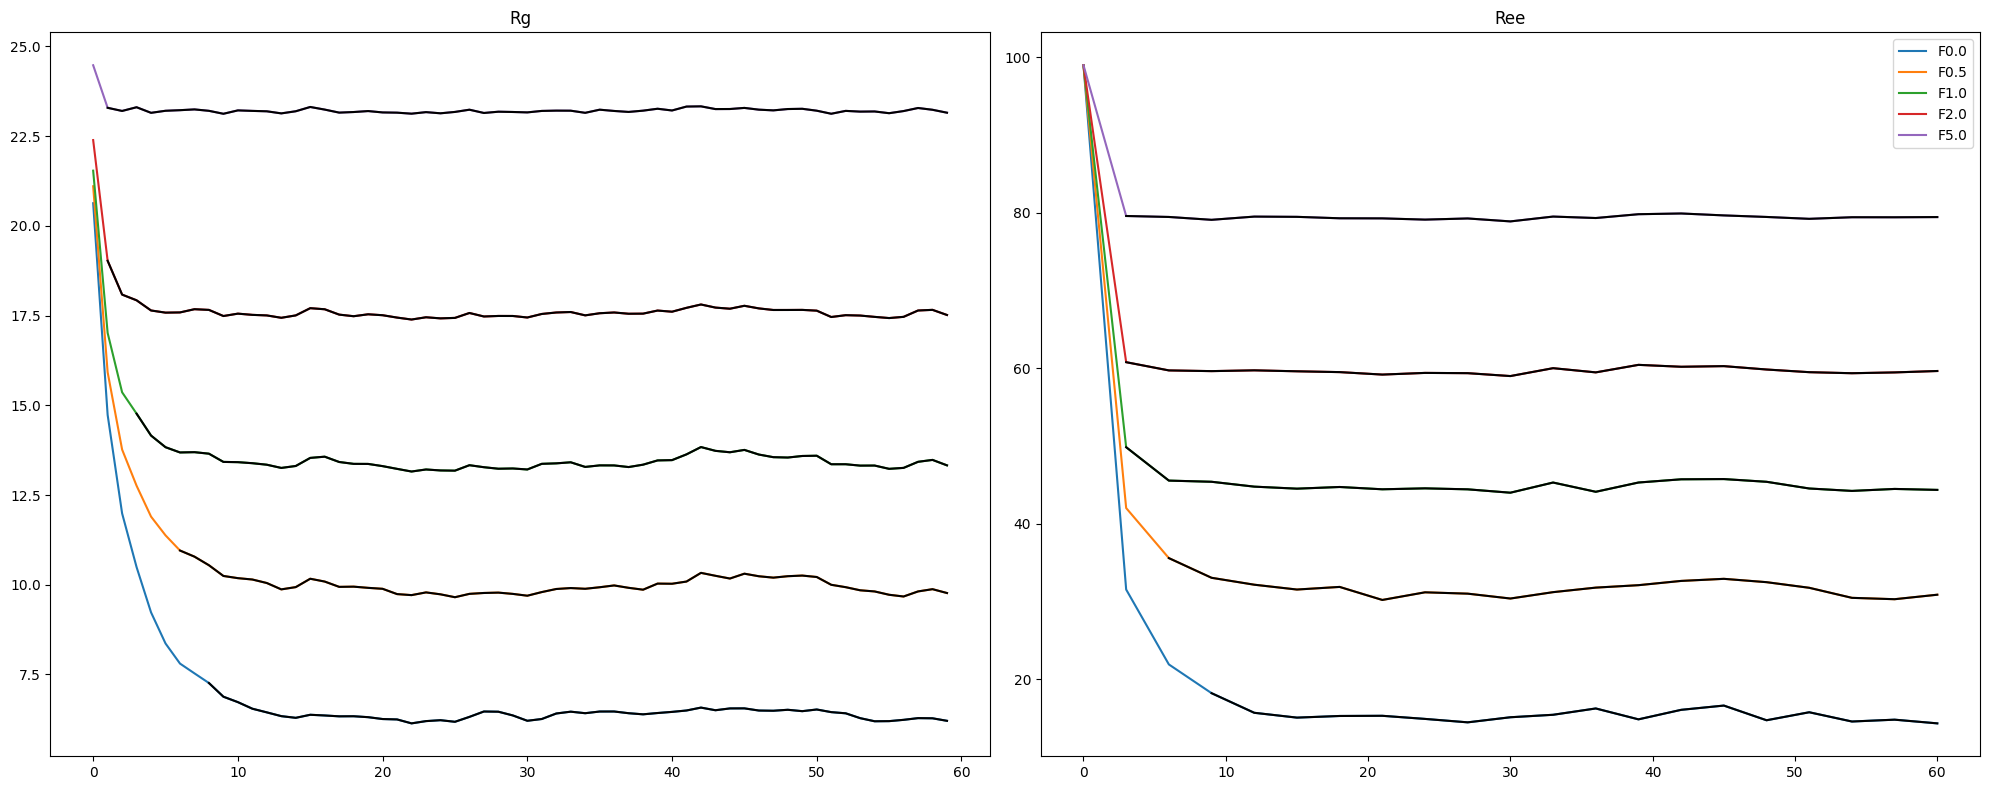

In [338]:
#T = 1
f = [0, 0.5, 1, 2, 5]
t = 1
Rgpaths = [
    '../block1/T1/force0/sv.rc2.5N100T1p1',
    '../block1/T1/force0.5/sv.rc2.5N100T1p1',
    '../block1/T1/force1/sv.rc2.5N100T1p1',
    '../block1/T1/force2/sv.rc2.5N100T1p1',
    '../block1/T1/force5/sv.rc2.5N100T1p1',
]
Reepaths = [
    '../block1/T1/force0/dump.rc2.5N100Tp1',
    '../block1/T1/force0.5/dump.rc2.5N100Tp1',
    '../block1/T1/force1/dump.rc2.5N100Tp1',
    '../block1/T1/force2/dump.rc2.5N100Tp1',
    '../block1/T1/force5/dump.rc2.5N100Tp1',
]

CGT1 = CGT(f, t, 1, Reepaths, Rgpaths)

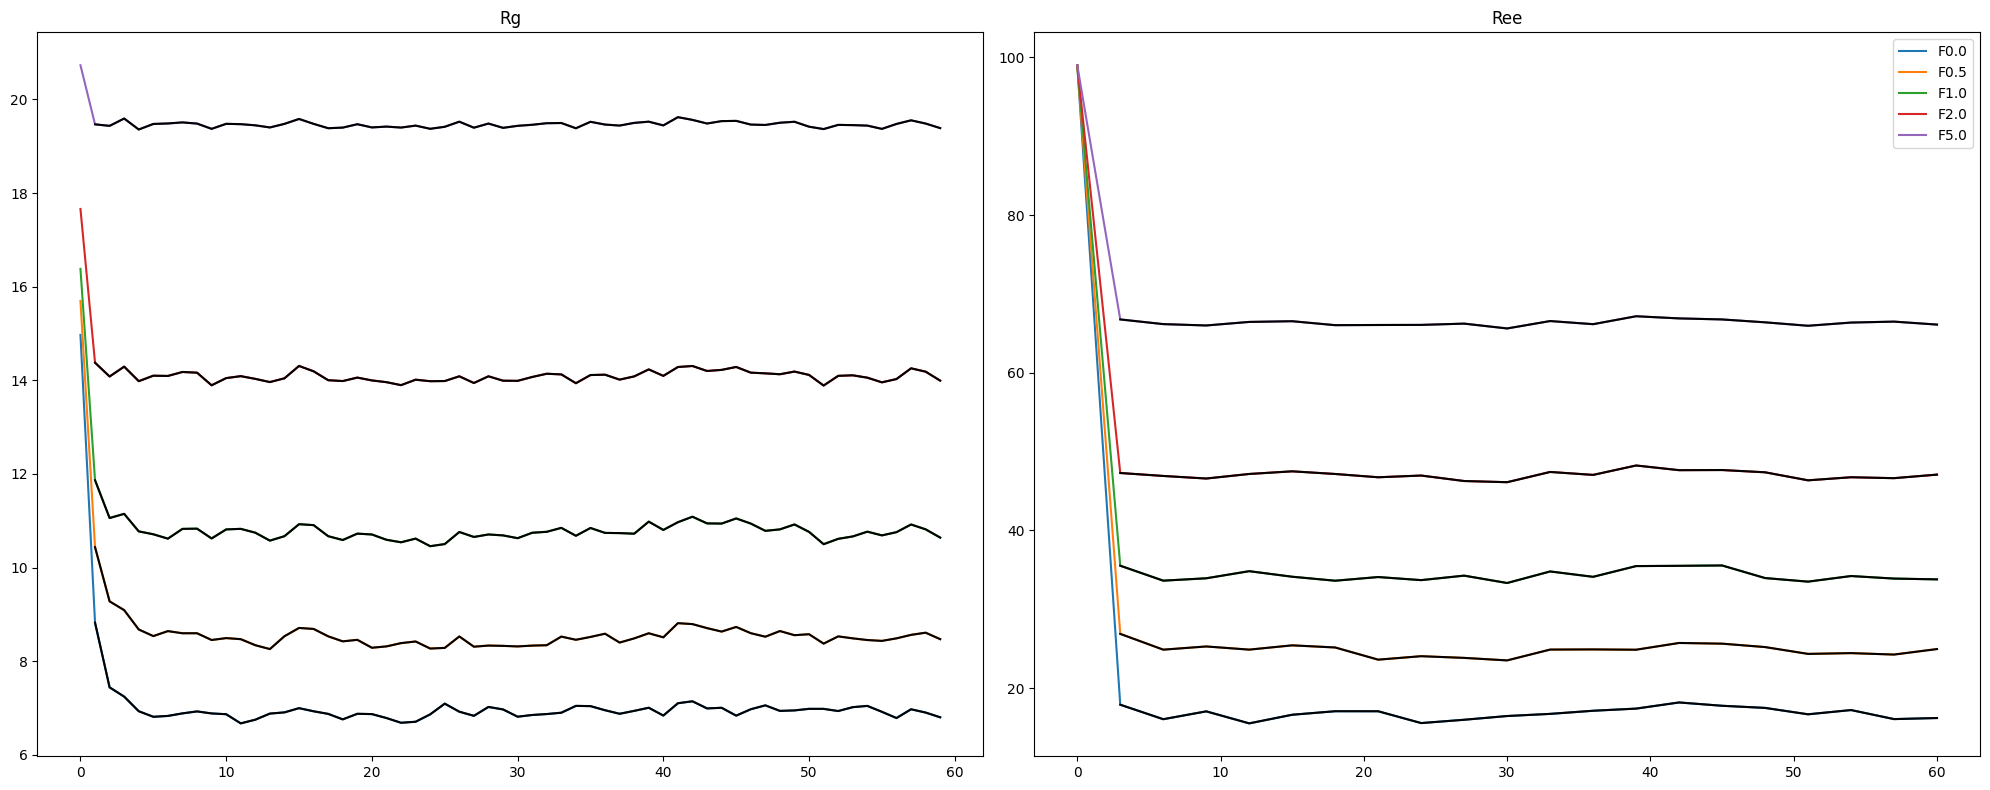

In [339]:
#T = 2
f = [0, 0.5, 1, 2, 5]
t = 2
Rgpaths = [
    '../block1/T2/force0/sv.rc2.5N100T2p1',
    '../block1/T2/force0.5/sv.rc2.5N100T2p1',
    '../block1/T2/force1/sv.rc2.5N100T2p1',
    '../block1/T2/force2/sv.rc2.5N100T2p1',
    '../block1/T2/force5/sv.rc2.5N100T2p1',
]
Reepaths = [
    '../block1/T2/force0/dump.rc2.5N100Tp1',
    '../block1/T2/force0.5/dump.rc2.5N100Tp1',
    '../block1/T2/force1/dump.rc2.5N100Tp1',
    '../block1/T2/force2/dump.rc2.5N100Tp1',
    '../block1/T2/force5/dump.rc2.5N100Tp1',
]

CGT2 = CGT(f, t, 1, Reepaths, Rgpaths)

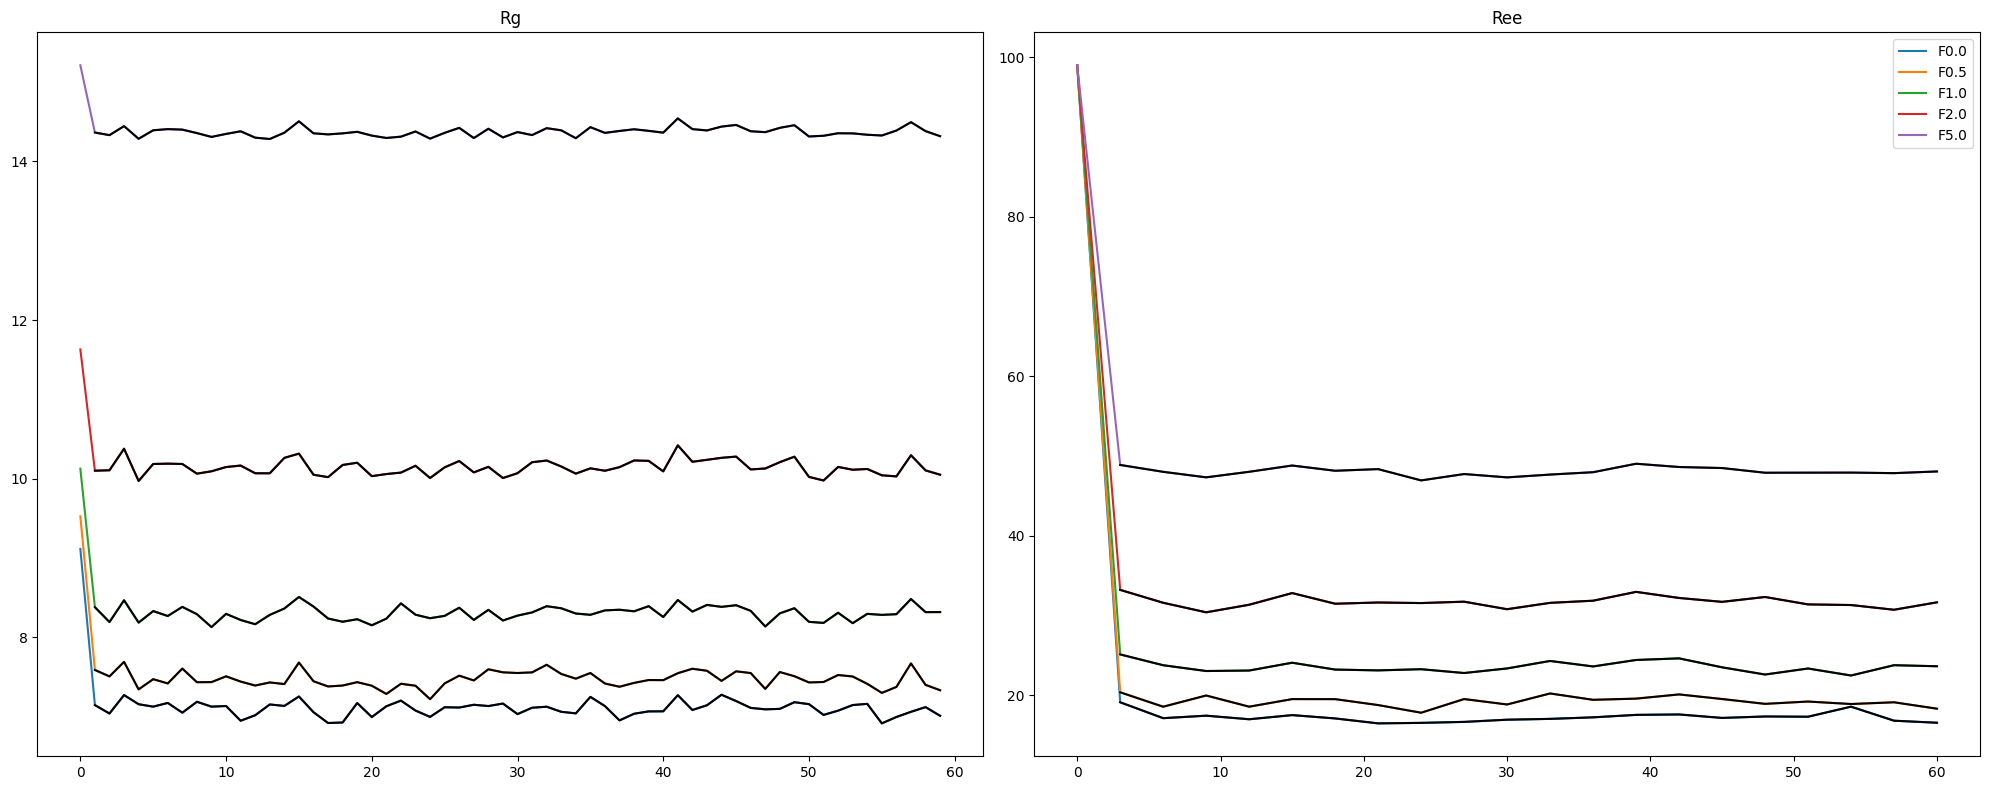

In [340]:
#T = 5
f = [0, 0.5, 1, 2, 5]
t = 5
Rgpaths = [
    '../block1/T5/force0/sv.rc2.5N100T5p1',
    '../block1/T5/force0.5/sv.rc2.5N100T5p1',
    '../block1/T5/force1/sv.rc2.5N100T5p1',
    '../block1/T5/force2/sv.rc2.5N100T5p1',
    '../block1/T5/force5/sv.rc2.5N100T5p1',
]
Reepaths = [
    '../block1/T5/force0/dump.rc2.5N100Tp1',
    '../block1/T5/force0.5/dump.rc2.5N100Tp1',
    '../block1/T5/force1/dump.rc2.5N100Tp1',
    '../block1/T5/force2/dump.rc2.5N100Tp1',
    '../block1/T5/force5/dump.rc2.5N100Tp1',
]

CGT5 = CGT(f, t, 1, Reepaths, Rgpaths)

In [ ]:
with open('Block1_CGT.pkl', 'wb') as file:
    pickle.dump(CGT01, file)
    pickle.dump(CGT03, file)
    pickle.dump(CGT04, file)
    pickle.dump(CGT05, file)
    pickle.dump(CGT1, file)
    pickle.dump(CGT2, file)
    pickle.dump(CGT5, file)

## Block 5

#### Unloading

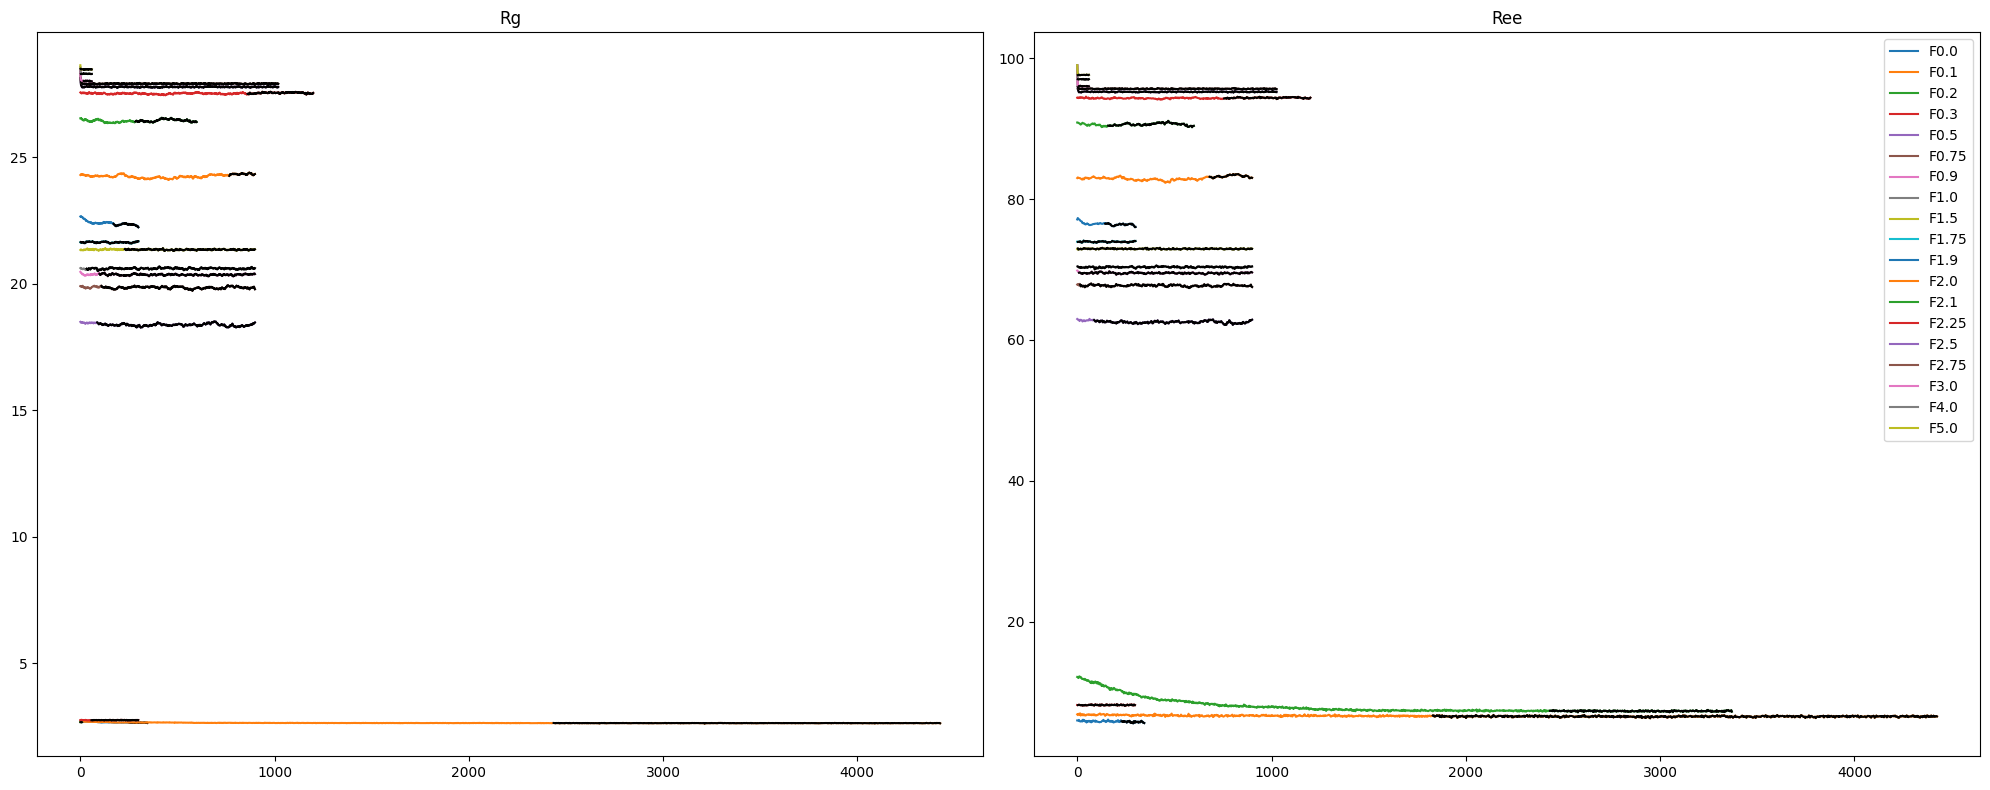

In [2]:
#T = 0.1
f = [0, 0.1, 0.2, 0.3, 0.5, 0.75, 0.9, 1, 1.5, 1.75, 1.9, 2, 2.1, 2.25, 2.5, 2.75, 3, 4, 5]
t = 0.1

Reepaths=[
    '../block5/T0.1/force0/p9/dump',
    '../block5/T0.1/force0.1/p5/dump',
    '../block5/T0.1/force0.2/p7/dump.rc2.5N100Tp1',
    '../block5/T0.1/force0.3/p10/dump.rc2.5N100Tp1',
    '../block5/T0.1/force0.5/dumpF0.5',
    '../block5/T0.1/force0.75/dumpF0.75',
    '../block5/T0.1/force0.9/p2/dump.rc2.5N100Tp1',
    '../block5/T0.1/force1/p3/dump.rc2.5N100Tp1',
    '../block5/T0.1/force1.5/p3/dump.rc2.5N100Tp1',
    '../block5/T0.1/force1.75/p2/dump.rc2.5N100Tp1',
    '../block5/T0.1/force1.9/p2/dump.rc2.5N100Tp1',
    '../block5/T0.1/force2/p5/dump.rc2.5N100Tp1',
    '../block5/T0.1/force2.1/dumpF2.1',
    '../block5/T0.1/force2.25/dumpF2.25',
    '../block5/T0.1/force2.5/dumpF2.5',
    '../block5/T0.1/force2.75/dumpF2.75',
    '../block5/T0.1/force3/dump.rc2.5N100Tp1',
    '../block5/T0.1/force4/dump.rc2.5N100Tp1',
    '../block5/T0.1/force5/dump.rc2.5N100Tp1',
]

Rgpaths = [
    '../block5/T0.1/force0/p9/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force0.1/p5/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force0.2/p7/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force0.3/p10/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force0.5/RgF0.5',
    '../block5/T0.1/force0.75/RgF0.75',
    '../block5/T0.1/force0.9/p2/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force1/p3/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force1.5/p3/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force1.75/p2/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force1.9/p2/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force2/p5/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force2.1/RgF2.1',
    '../block5/T0.1/force2.25/RgF2.25',
    '../block5/T0.1/force2.5/RgF2.5',
    '../block5/T0.1/force2.75/RgF2.75',
    '../block5/T0.1/force3/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force4/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force5/sv.rc2.5N100T0.1p1',
]

CGT01 = CGT(f, t, 5, Reepaths, Rgpaths)

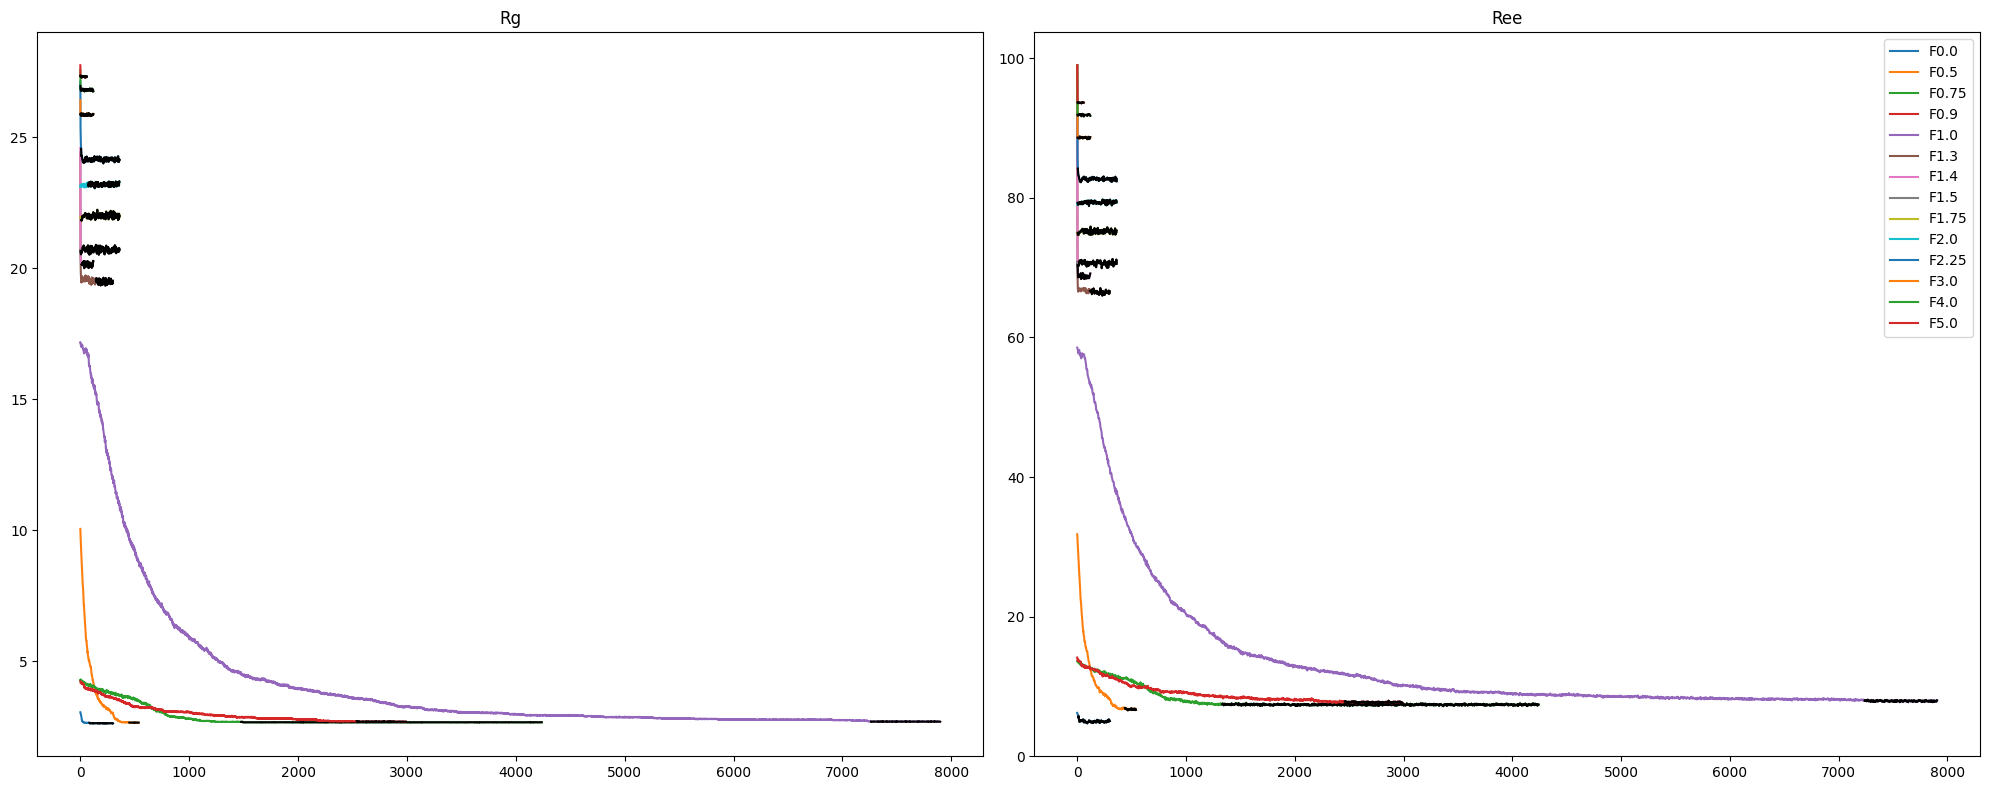

In [245]:
#T = 0.3
f = [0, 0.5, 0.75, 0.9, 1, 1.3, 1.4, 1.5, 1.75, 2, 2.25, 3, 4, 5]
t = 0.3
Rgpaths = [
    '../block5/T0.3/force0/p2/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force0.5/p2/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force0.75/p4/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force0.9/p2/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force1/p3/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force1.3/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force1.4/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force1.5/p2/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force1.75/p2/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force2/p2/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force2.25/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force3/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force4/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force5/sv.rc2.5N100T0.3p1'
]
Reepaths = [
    '../block5/T0.3/force0/p2/dump.rc2.5N100Tp1',
    '../block5/T0.3/force0.5/p2/dump.rc2.5N100Tp1',
    '../block5/T0.3/force0.75/p4/dump.rc2.5N100Tp1',
    '../block5/T0.3/force0.9/p2/dump.rc2.5N100Tp1',
    '../block5/T0.3/force1/p3/dump.rc2.5N100Tp1',
    '../block5/T0.3/force1.3/dump.rc2.5N100Tp1',
    '../block5/T0.3/force1.4/dump.rc2.5N100Tp1',
    '../block5/T0.3/force1.5/p2/dump',
    '../block5/T0.3/force1.75/p2/dump',
    '../block5/T0.3/force2/p2/dump.rc2.5N100Tp1',
    '../block5/T0.3/force2.25/dump.rc2.5N100Tp1',
    '../block5/T0.3/force3/dump.rc2.5N100Tp1',
    '../block5/T0.3/force4/dump.rc2.5N100Tp1',
    '../block5/T0.3/force5/dump.rc2.5N100Tp1'
]

CGT03 = CGT(f, t, 5, Reepaths, Rgpaths)

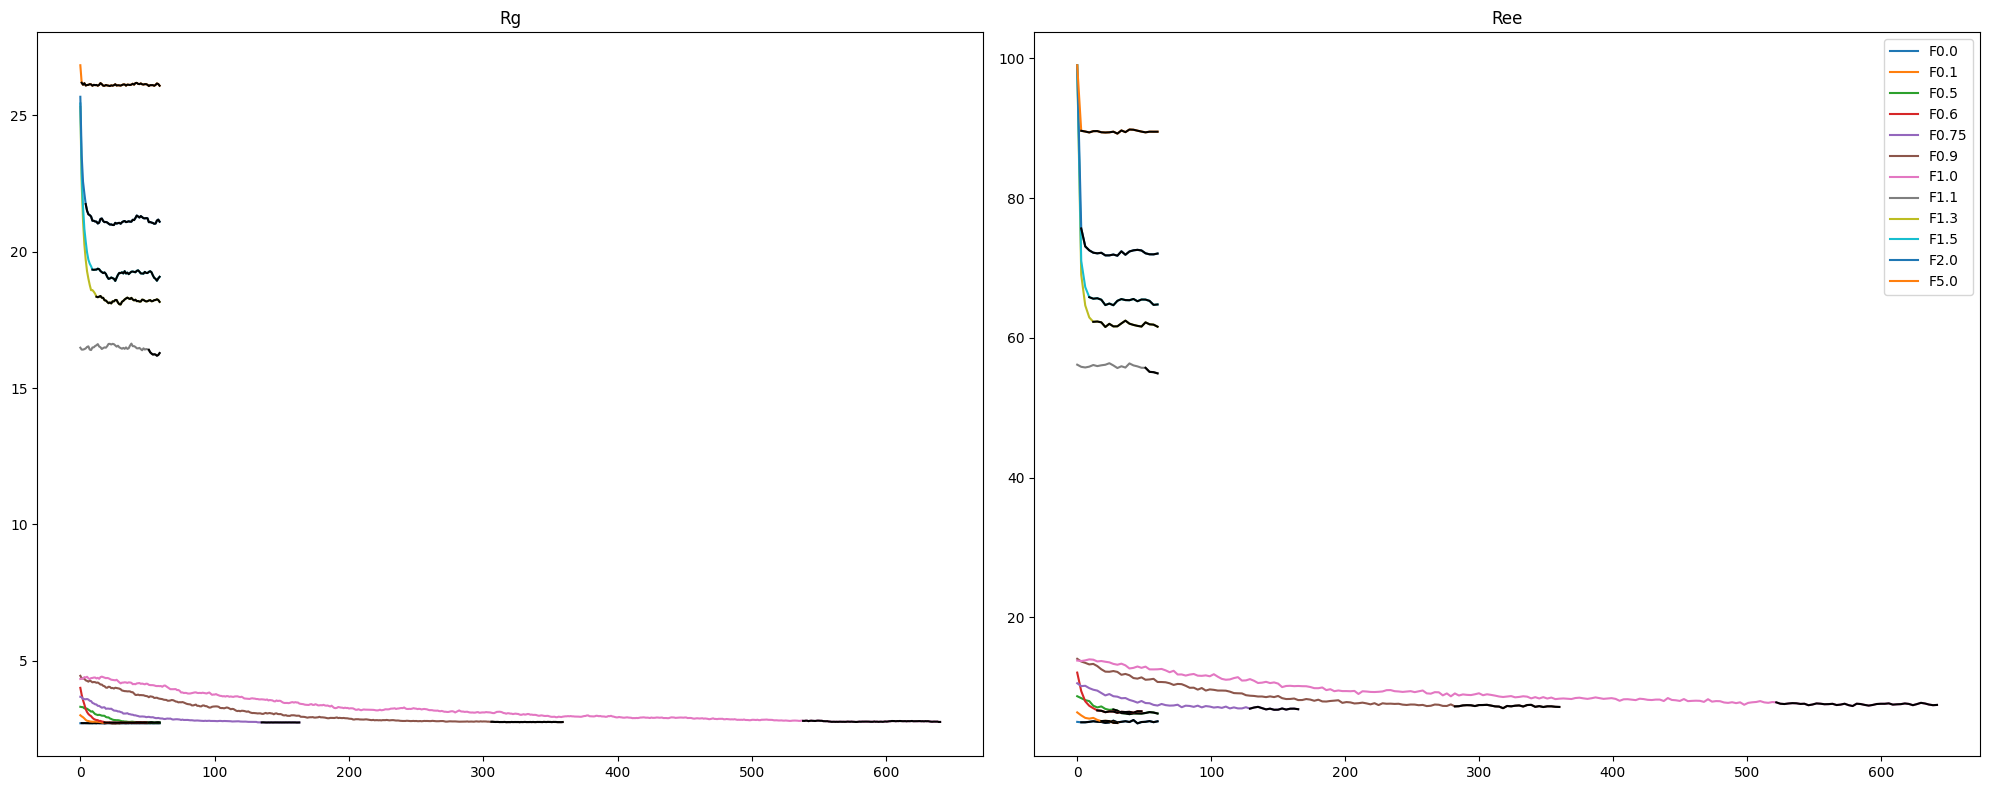

In [206]:
#T = 0.5
f = [0, 0.1, 0.5, 0.6, 0.75, 0.9, 1, 1.1, 1.3, 1.5, 2, 5]
t = 0.5

Rgpaths = [
    '../block5/T0.5/force0/p2/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force0.1/p2/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force0.5/p2/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force0.6/p2/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force0.75/p3/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force0.9/p4/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force1/p5/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force1.1/p2/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force1.3/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force1.5/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force2/sv.rc2.5N100T0.5p1',
    '../block5/T0.5/force5/sv.rc2.5N100T0.5p1'
    
]
Reepaths = [
    '../block5/T0.5/force0/p2/dump',
    '../block5/T0.5/force0.1/p2/dump.rc2.5N100Tp1',
    '../block5/T0.5/force0.5/p2/dump.rc2.5N100Tp1',
    '../block5/T0.5/force0.6/p2/dump.rc2.5N100Tp1',
    '../block5/T0.5/force0.75/p3/dump.rc2.5N100Tp1',
    '../block5/T0.5/force0.9/p4/dump.rc2.5N100Tp1',
    '../block5/T0.5/force1/p5/dump.rc2.5N100Tp1',
    '../block5/T0.5/force1.1/p2/dump.rc2.5N100Tp1',
    '../block5/T0.5/force1.3/dump.rc2.5N100Tp1',
    '../block5/T0.5/force1.5/dump.rc2.5N100Tp1',
    '../block5/T0.5/force2/dump.rc2.5N100Tp1',
    '../block5/T0.5/force5/dump.rc2.5N100Tp1'
]

CGT05 = CGT(f, t, 5, Reepaths, Rgpaths)

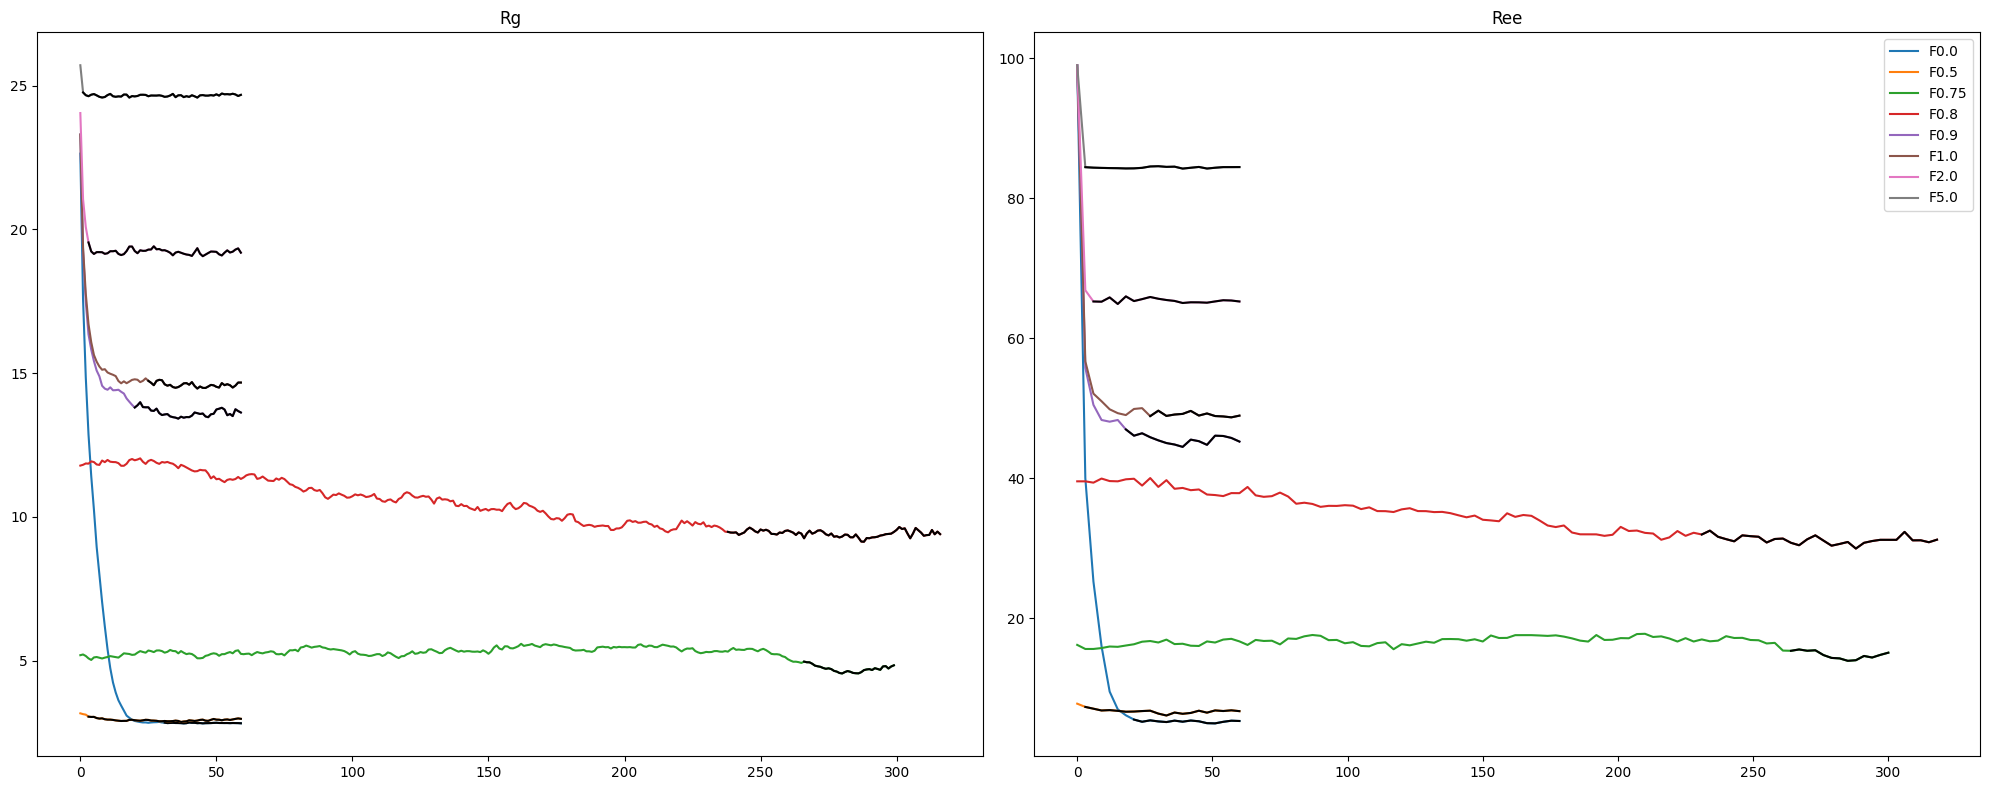

In [207]:
#T = 0.75
f = [0, 0.5, 0.75, 0.8, 0.9, 1, 2, 5]
t = 0.75

Rgpaths = [
    '../block5/T0.75/force0/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force0.5/p2/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force0.75/p4/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force0.8/p2/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force0.9/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force1/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force2/sv.rc2.5N100T0.75p1',
    '../block5/T0.75/force5/sv.rc2.5N100T0.75p1'
]
Reepaths = [
    '../block5/T0.75/force0/dump.rc2.5N100Tp1',
    '../block5/T0.75/force0.5/p2/dump.rc2.5N100Tp1',
    '../block5/T0.75/force0.75/p4/dump.rc2.5N100Tp1',
    '../block5/T0.75/force0.8/p2/dump.rc2.5N100Tp1',
    '../block5/T0.75/force0.9/dump.rc2.5N100Tp1',
    '../block5/T0.75/force1/dump.rc2.5N100Tp1',
    '../block5/T0.75/force2/dump.rc2.5N100Tp1',
    '../block5/T0.75/force5/dump.rc2.5N100Tp1'
]

CGT075 = CGT(f, t, 5, Reepaths, Rgpaths)

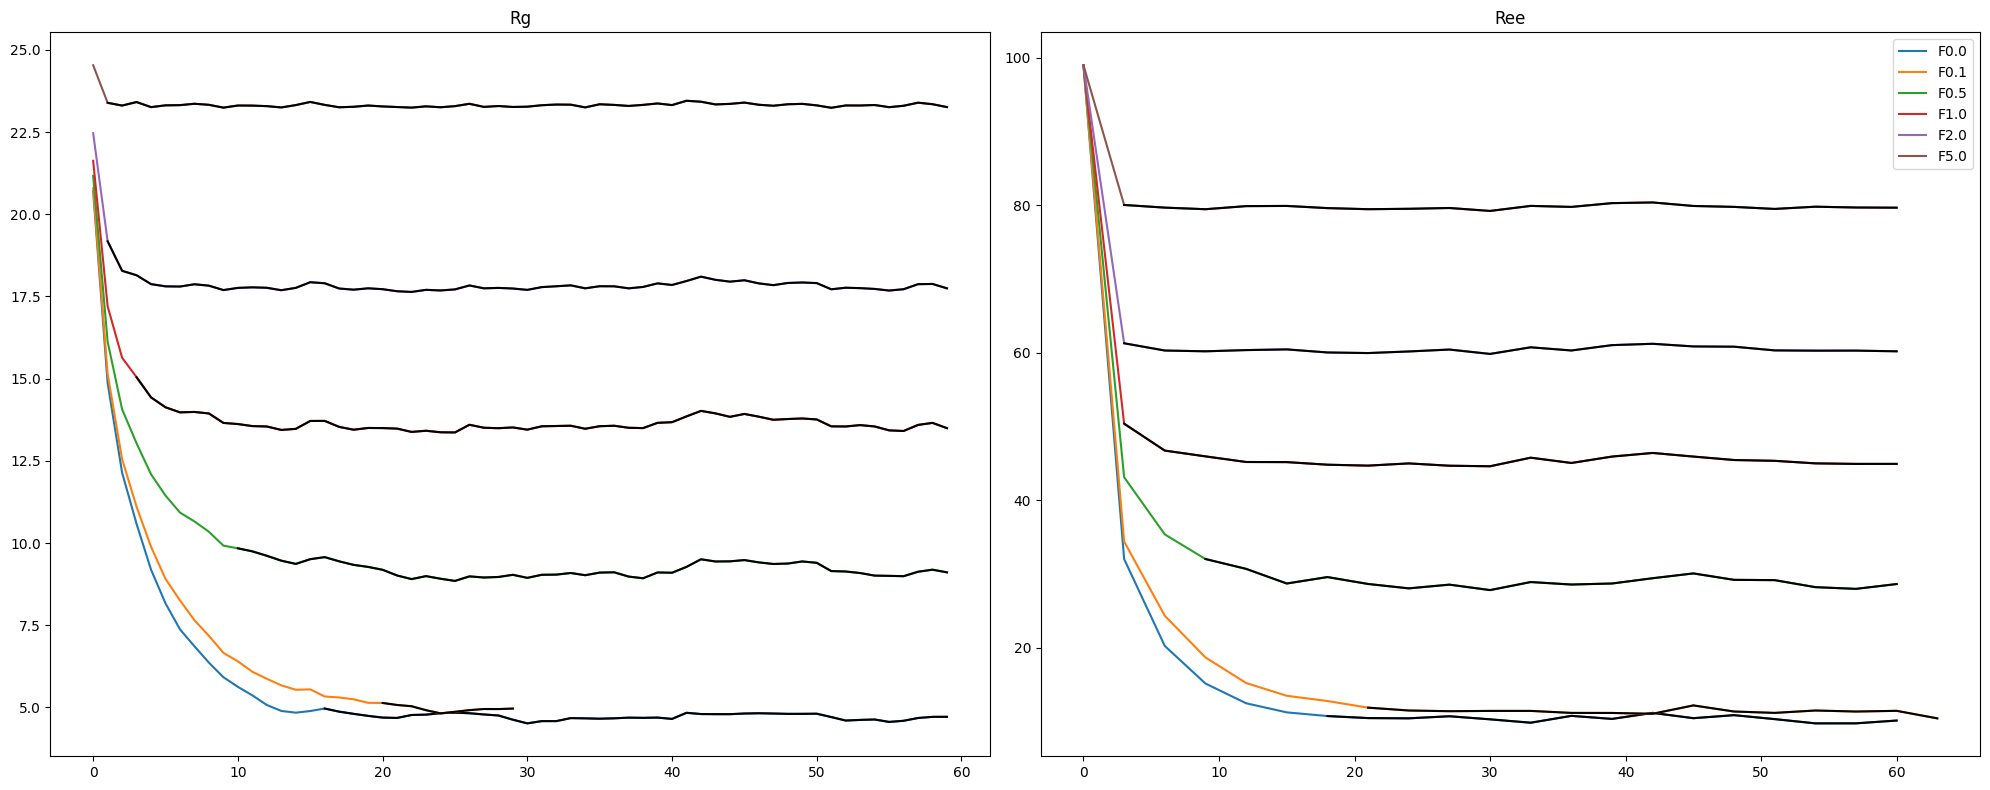

In [208]:
#T = 1
f = [0, 0.1, 0.5, 1, 2, 5]
t = 1

Rgpaths = [
    '../block5/T1/force0/sv.rc2.5N100T1p1',
    '../block5/T1/force0.1/sv.rc2.5N100T1p1',
    '../block5/T1/force0.5/sv.rc2.5N100T1p1',
    '../block5/T1/force1/sv.rc2.5N100T1p1',
    '../block5/T1/force2/sv.rc2.5N100T1p1',
    '../block5/T1/force5/sv.rc2.5N100T1p1'
]
Reepaths = [
    '../block5/T1/force0/dump.rc2.5N100Tp1',
    '../block5/T1/force0.1/dump.rc2.5N100Tp1',
    '../block5/T1/force0.5/dump.rc2.5N100Tp1',
    '../block5/T1/force1/dump.rc2.5N100Tp1',
    '../block5/T1/force2/dump.rc2.5N100Tp1',
    '../block5/T1/force5/dump.rc2.5N100Tp1',
]

CGT1 = CGT(f, t, 5, Reepaths, Rgpaths)

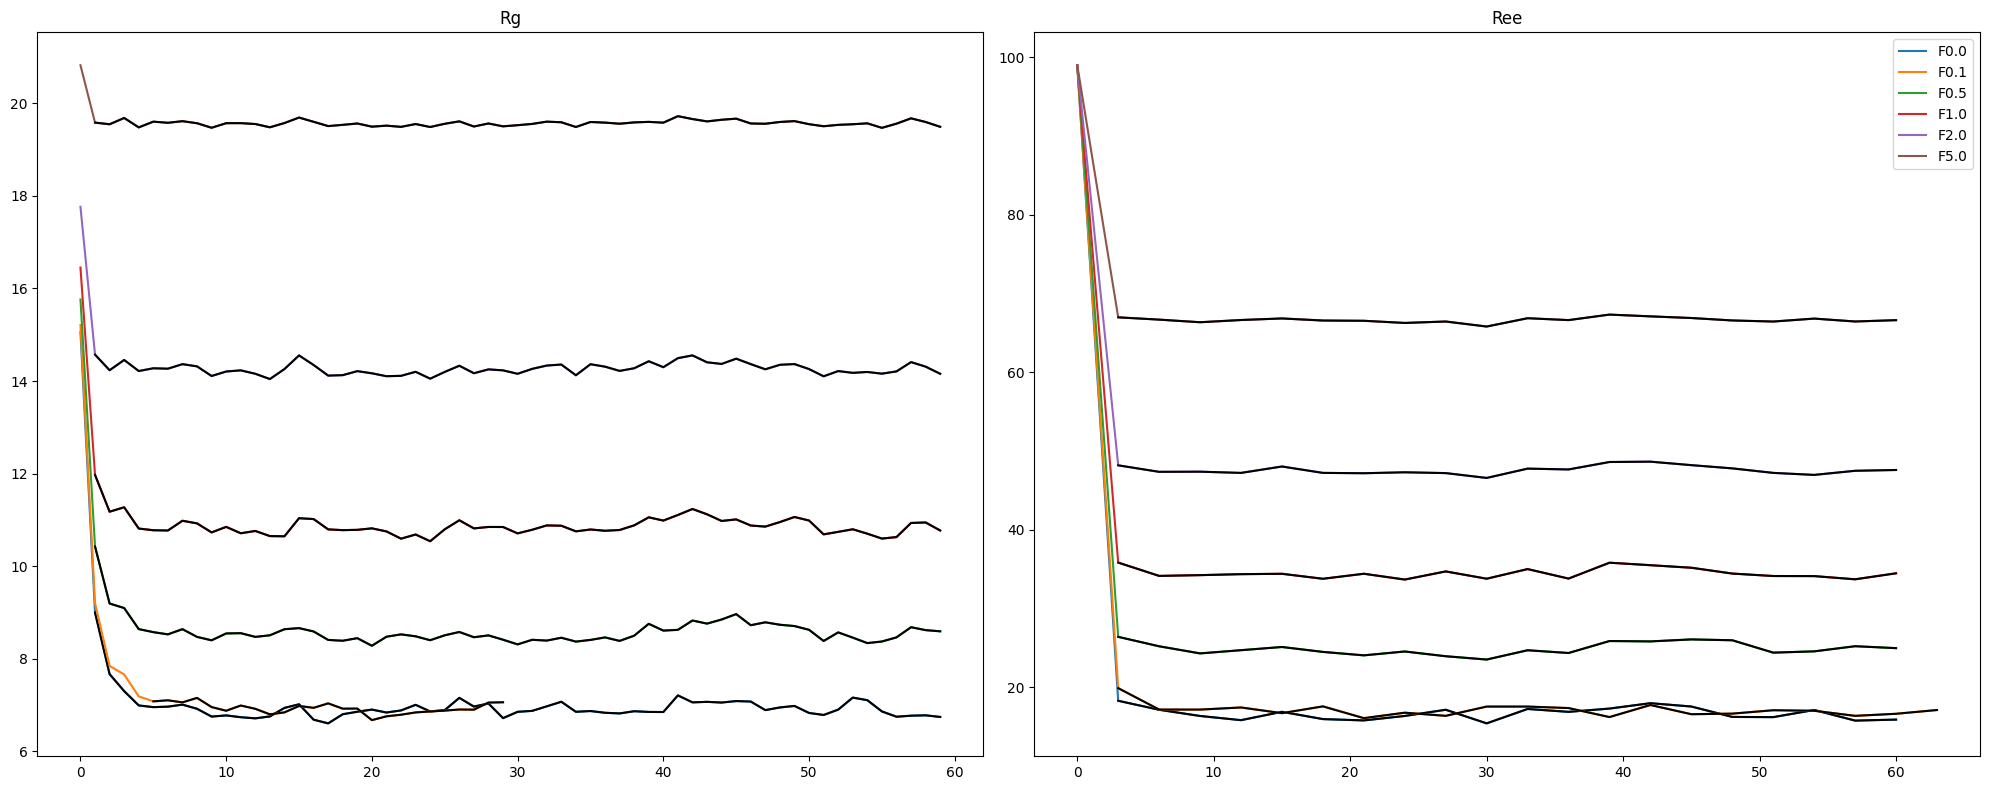

In [209]:
#T = 2
f = [0, 0.1, 0.5, 1, 2, 5]
t = 2

Rgpaths = [
    '../block5/T2/force0/sv.rc2.5N100T2p1',
    '../block5/T2/force0.1/sv.rc2.5N100T2p1',
    '../block5/T2/force0.5/sv.rc2.5N100T2p1',
    '../block5/T2/force1/sv.rc2.5N100T2p1',
    '../block5/T2/force2/sv.rc2.5N100T2p1',
    '../block5/T2/force5/sv.rc2.5N100T2p1',
]
Reepaths = [
    '../block5/T2/force0/dump.rc2.5N100Tp1',
    '../block5/T2/force0.1/dump.rc2.5N100Tp1',
    '../block5/T2/force0.5/dump.rc2.5N100Tp1',
    '../block5/T2/force1/dump.rc2.5N100Tp1',
    '../block5/T2/force2/dump.rc2.5N100Tp1',
    '../block5/T2/force5/dump.rc2.5N100Tp1',
]

CGT2 = CGT(f, t, 5, Reepaths, Rgpaths)

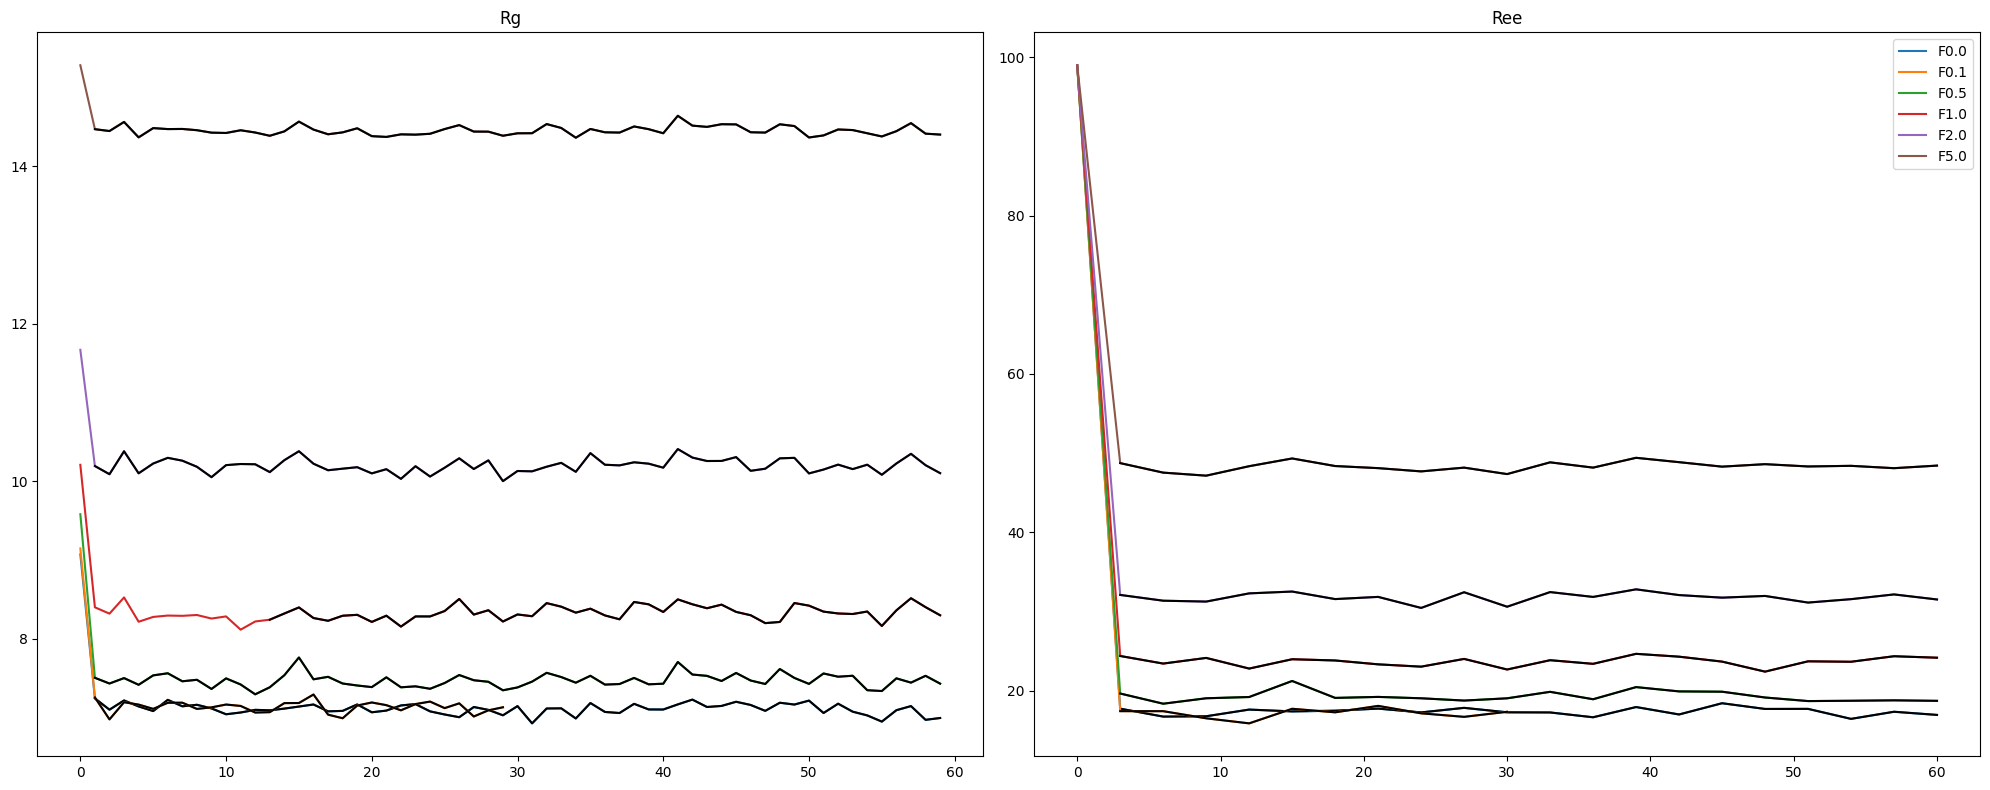

In [210]:
#T = 5
f = [0, 0.1, 0.5, 1, 2, 5]
t = 5

Rgpaths = [
    '../block5/T5/force0/sv.rc2.5N100T5p1',
    '../block5/T5/force0.1/sv.rc2.5N100T5p1',
    '../block5/T5/force0.5/sv.rc2.5N100T5p1',
    '../block5/T5/force1/sv.rc2.5N100T5p1',
    '../block5/T5/force2/sv.rc2.5N100T5p1',
    '../block5/T5/force5/sv.rc2.5N100T5p1',
]

Reepaths = [
    '../block5/T5/force0/dump.rc2.5N100Tp1',
    '../block5/T5/force0.1/dump.rc2.5N100Tp1',
    '../block5/T5/force0.5/dump.rc2.5N100Tp1',
    '../block5/T5/force1/dump.rc2.5N100Tp1',
    '../block5/T5/force2/dump.rc2.5N100Tp1',
    '../block5/T5/force5/dump.rc2.5N100Tp1',
]

CGT5 = CGT(f, t, 5, Reepaths, Rgpaths)

In [211]:
with open('Block5_CGT.pkl', 'wb') as file:
    pickle.dump(CGT01, file)
    pickle.dump(CGT03, file)
    pickle.dump(CGT05, file)
    pickle.dump(CGT075, file)
    pickle.dump(CGT1, file)
    pickle.dump(CGT2, file)
    pickle.dump(CGT5, file)

#### Loading

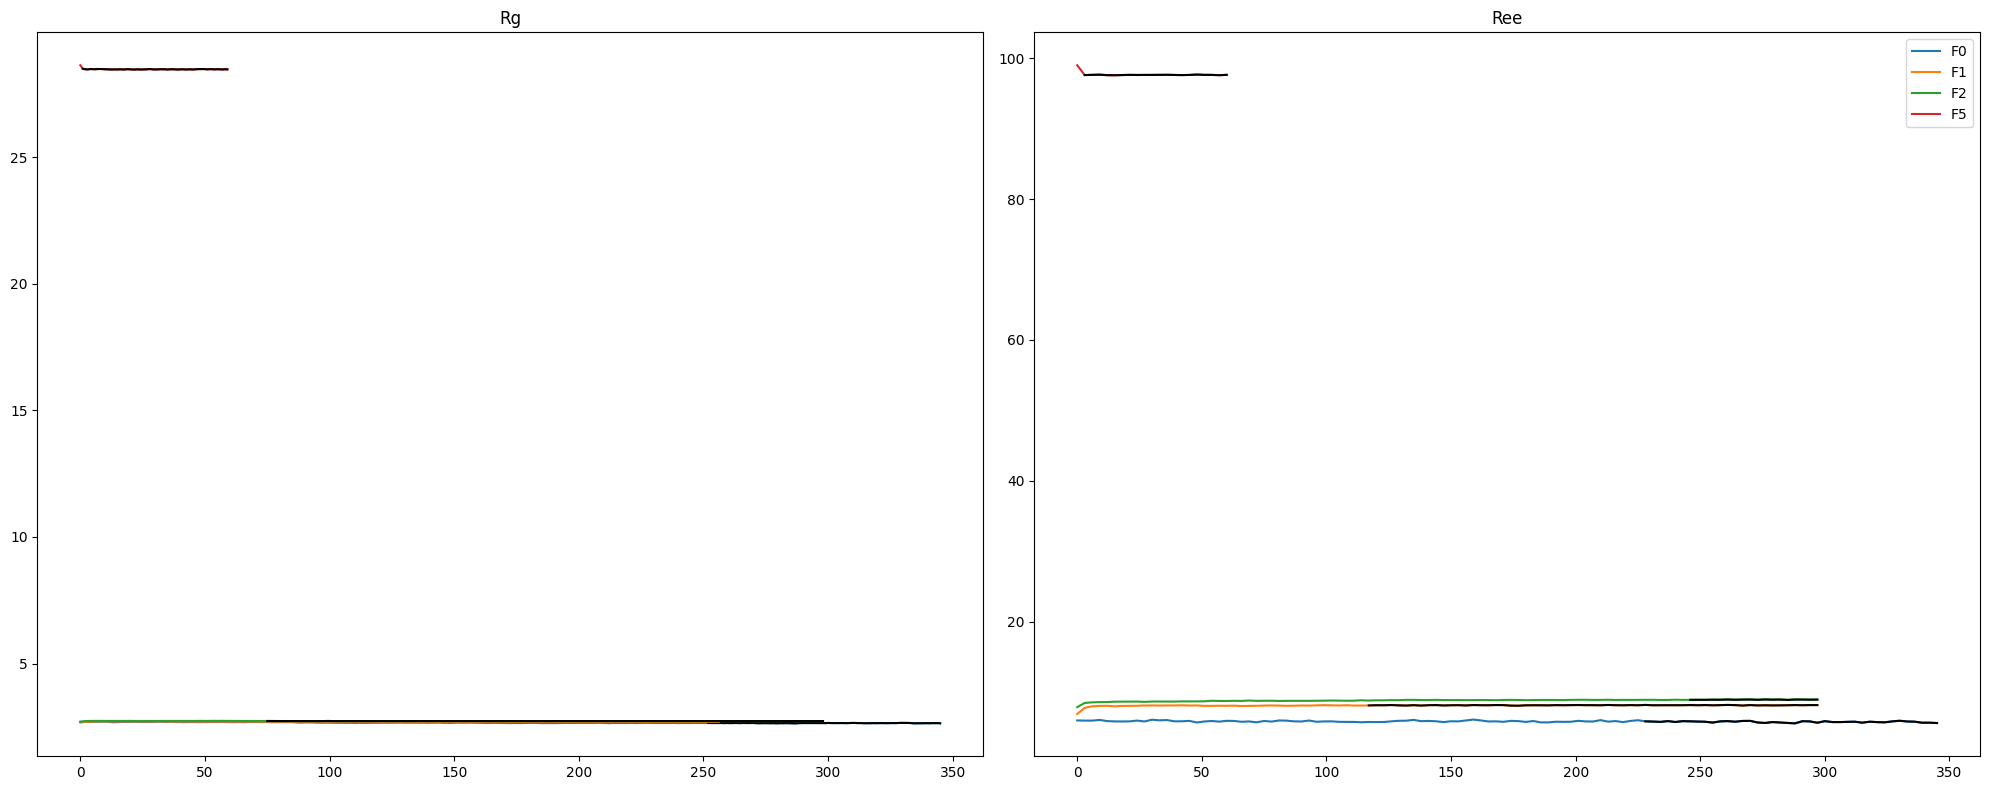

In [4]:
#T = 0.1
f = [0, 1, 2, 5]
t = 0.1

Rgpaths = [
    '../block5/T0.1/force0/p9/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/Hysteresis/force1/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/Hysteresis/force2/sv.rc2.5N100T0.1p1',
    '../block5/T0.1/force5/sv.rc2.5N100T0.1p1',
]

Reepaths = [
    '../block5/T0.1/force0/p9/dump',
    '../block5/T0.1/Hysteresis/force1/dump.rc2.5N100Tp1',
    '../block5/T0.1/Hysteresis/force2/dump.rc2.5N100Tp1',
    '../block5/T0.1/force5/dump.rc2.5N100Tp1',
]

CGT01_H = CGT(f, t, 5, Reepaths, Rgpaths)

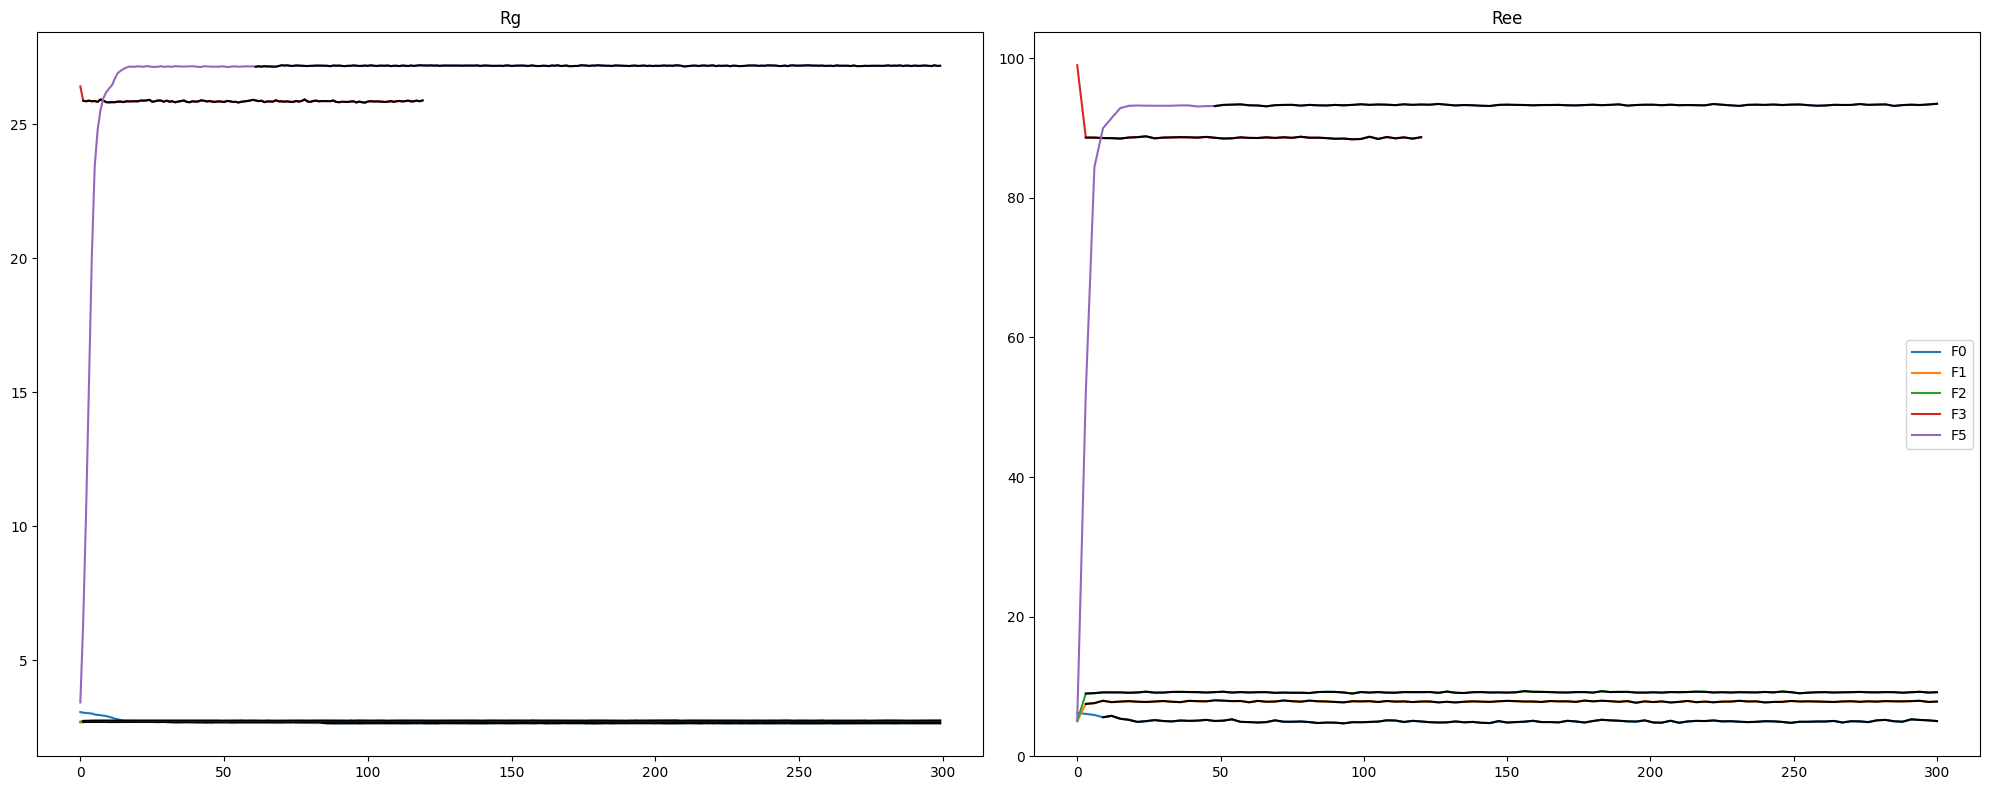

In [5]:
#T = 0.3
f = [0, 1, 2, 3, 5]
t = 0.3

Rgpaths = [
    '../block5/T0.3/force0/p2/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/Hysteresis/force1/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/Hysteresis/force2/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/force3/sv.rc2.5N100T0.3p1',
    '../block5/T0.3/Hysteresis/force5/sv.rc2.5N100T0.3p1',
]

Reepaths = [
    '../block5/T0.3/force0/p2/dump.rc2.5N100Tp1',
    '../block5/T0.3/Hysteresis/force1/dump.rc2.5N100Tp1',
    '../block5/T0.3/Hysteresis/force2/dump.rc2.5N100Tp1',
    '../block5/T0.3/force3/dump.rc2.5N100Tp1',
    '../block5/T0.3/Hysteresis/force5/dump.rc2.5N100Tp1',
]

CGT03_H = CGT(f, t, 5, Reepaths, Rgpaths)

In [6]:
filename = 'Block5_CGT_H.pkl'

with open(filename, 'wb') as file:
    pickle.dump(CGT01_H, file)
    pickle.dump(CGT03_H, file)

## Block 10

#### Unloading

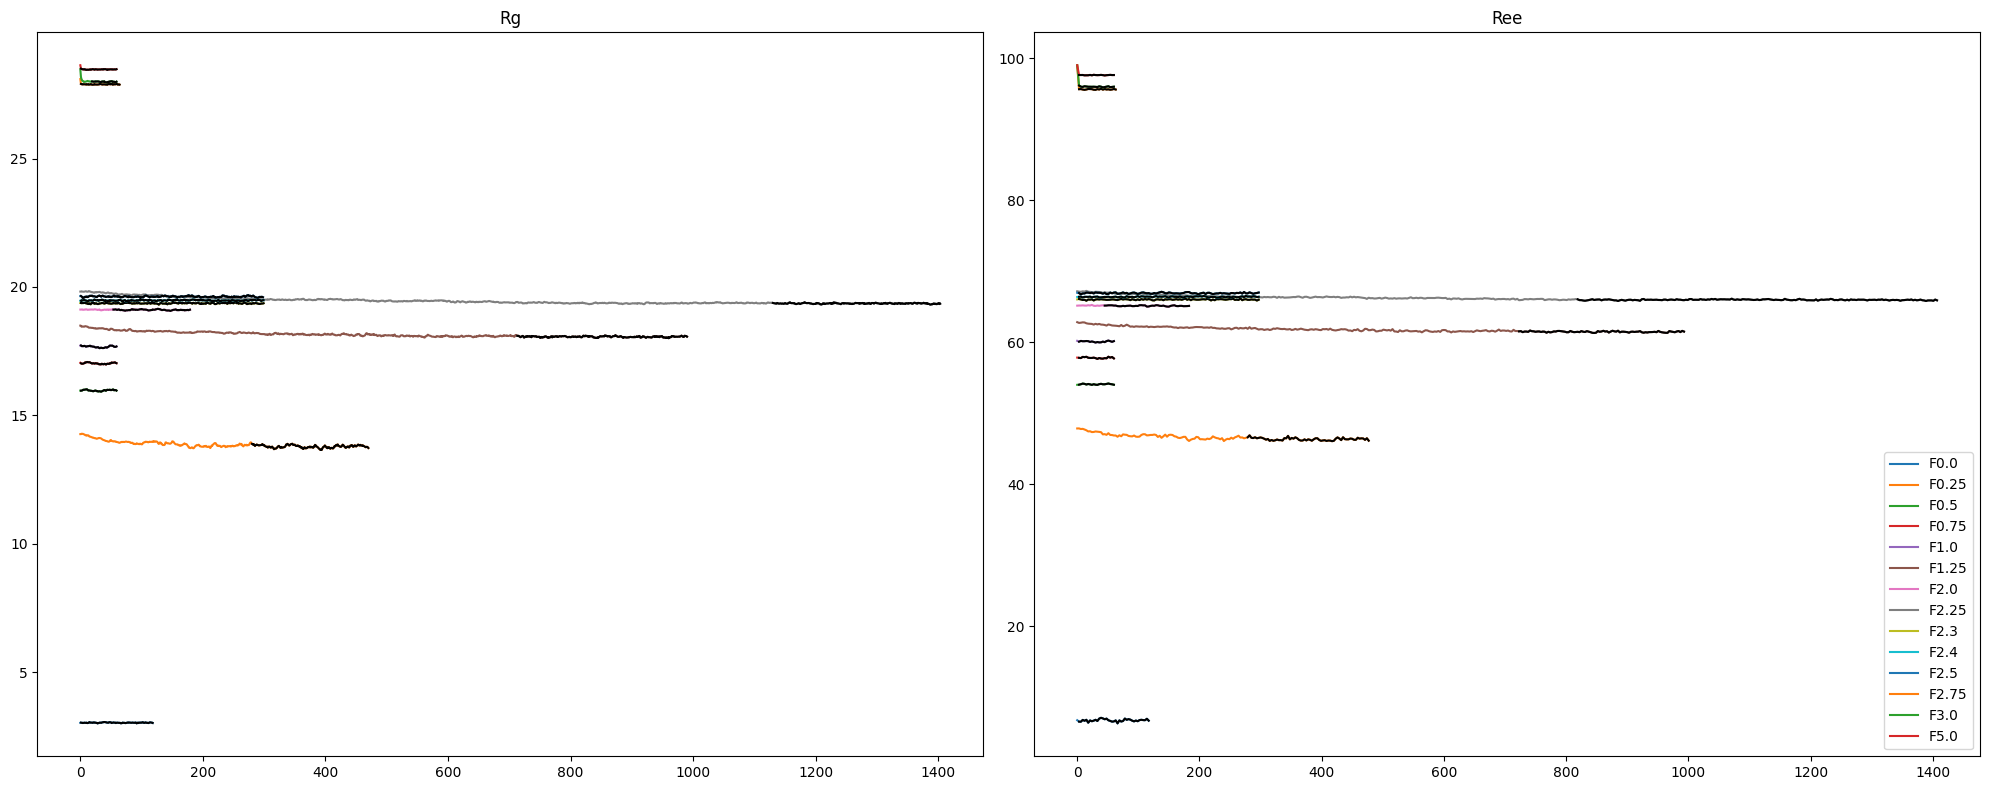

In [ ]:
#T = 0.1
f = [0, 0.25, 0.5, 0.75, 1, 1.25, 2, 2.25, 2.3, 2.4, 2.5, 2.75, 3, 5]
t = 0.1

Rgpaths = [
    '../block10/T0.1/force0/p4/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force0.25/p2/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force0.5/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force0.75/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force1/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force1.25/p4/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force2/RgF2',
    '../block10/T0.1/force2.25/p4/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force2.3/p4/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force2.4/p4/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force2.5/p5/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force2.75/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force3/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force5/sv.rc2.5N100T0.1p1',
]
Reepaths = [
    '../block10/T0.1/force0/p4/dump.rc2.5N100Tp1',
    '../block10/T0.1/force0.25/p2/dump.rc2.5N100Tp1',
    '../block10/T0.1/force0.5/dump.rc2.5N100Tp1',
    '../block10/T0.1/force0.75/dump.rc2.5N100Tp1',
    '../block10/T0.1/force1/dump.rc2.5N100Tp1',
    '../block10/T0.1/force1.25/p4/dump',
    '../block10/T0.1/force2/dumpF2',
    '../block10/T0.1/force2.25/p4/dump',
    '../block10/T0.1/force2.3/p4/dump',
    '../block10/T0.1/force2.4/p4/dump',
    '../block10/T0.1/force2.5/p5/dump',
    '../block10/T0.1/force2.75/dump',
    '../block10/T0.1/force3/dump.rc2.5N100Tp1',
    '../block10/T0.1/force5/dump.rc2.5N100Tp1',
]

CGT01 = CGT(f, t, 10, Reepaths, Rgpaths)

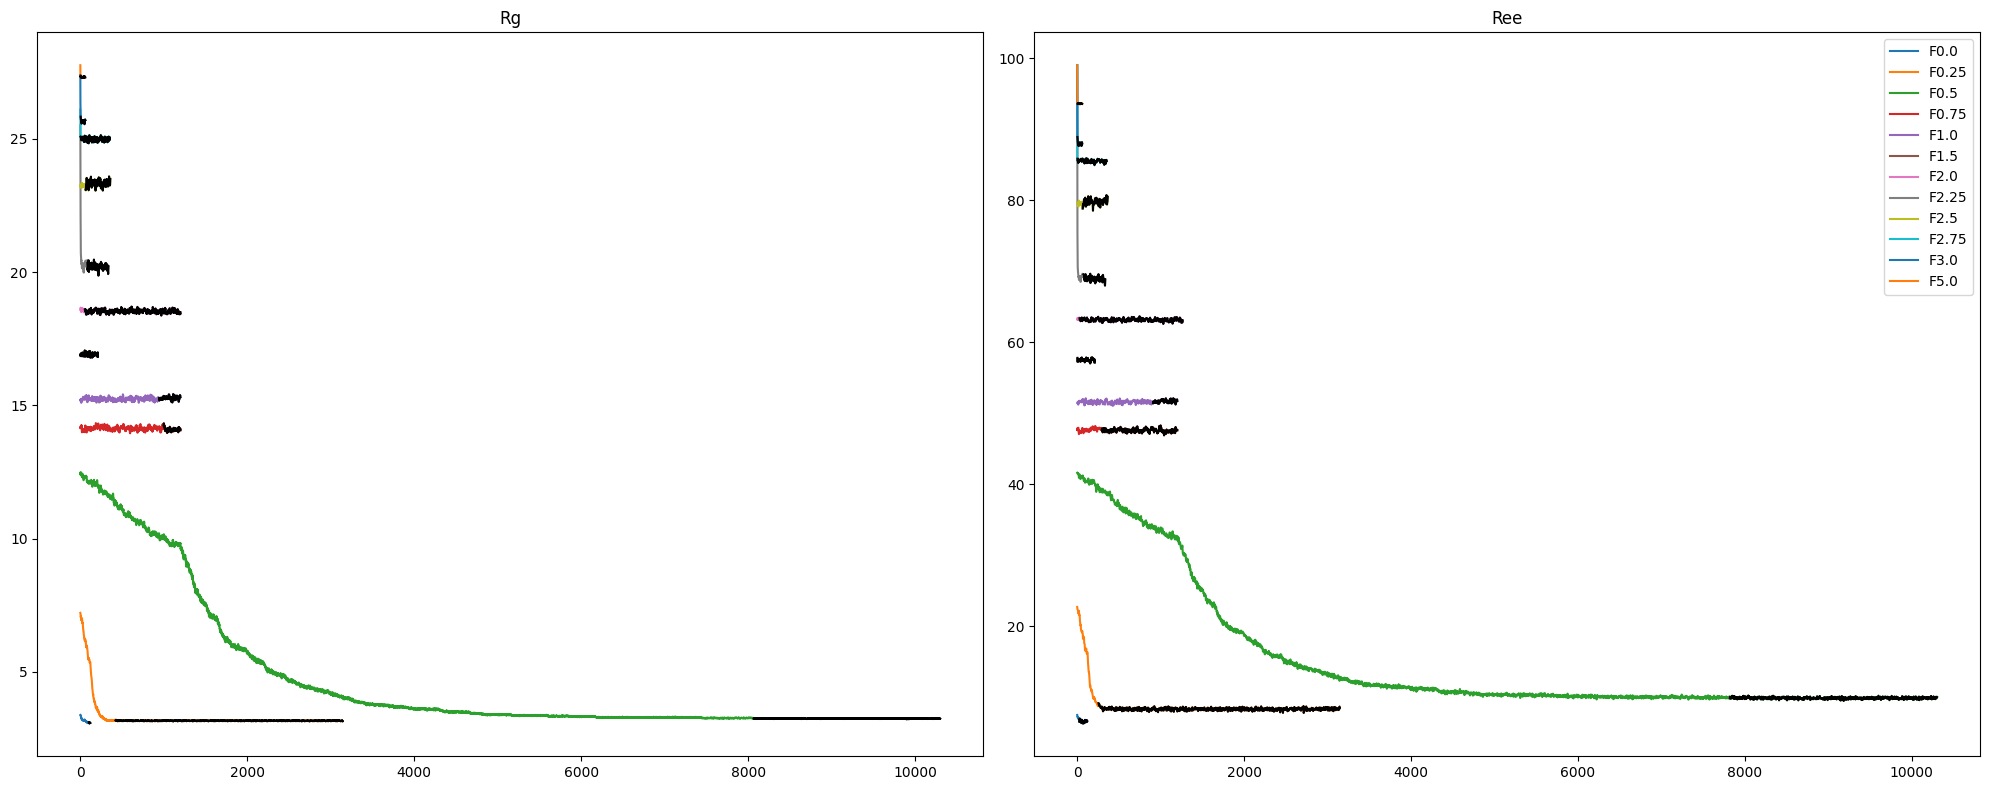

In [68]:
#T = 0.3
f = [0, 0.25, 0.5, 0.75, 1, 1.5, 2, 2.25, 2.5, 2.75, 3, 5]
t = 0.3

Rgpaths = [
    '../block10/T0.3/force0/p2/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force0.25/p2/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force0.5/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force0.75/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force1/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force1.5/p3/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force2/p2/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force2.25/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force2.5/p2/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force2.75/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force3/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/force5/sv.rc2.5N100T0.3p1',
]
Reepaths = [
    '../block10/T0.3/force0/p2/dump.rc2.5N100Tp1',
    '../block10/T0.3/force0.25/p2/dump.rc2.5N100Tp1',
    '../block10/T0.3/force0.5/dump',
    '../block10/T0.3/force0.75/dump',
    '../block10/T0.3/force1/dump',
    '../block10/T0.3/force1.5/p3/dump',
    '../block10/T0.3/force2/p2/dump',
    '../block10/T0.3/force2.25/dump',
    '../block10/T0.3/force2.5/p2/dump.rc2.5N100Tp1',
    '../block10/T0.3/force2.75/dump',
    '../block10/T0.3/force3/dump.rc2.5N100Tp1',
    '../block10/T0.3/force5/dump.rc2.5N100Tp1',
]

CGT03 = CGT(f, t, 10, Reepaths, Rgpaths)

In [69]:
filename = 'Block10_CGT.pkl'

with open(filename, 'wb') as file:
    pickle.dump(CGT01, file)
    pickle.dump(CGT03, file)

#### Loading

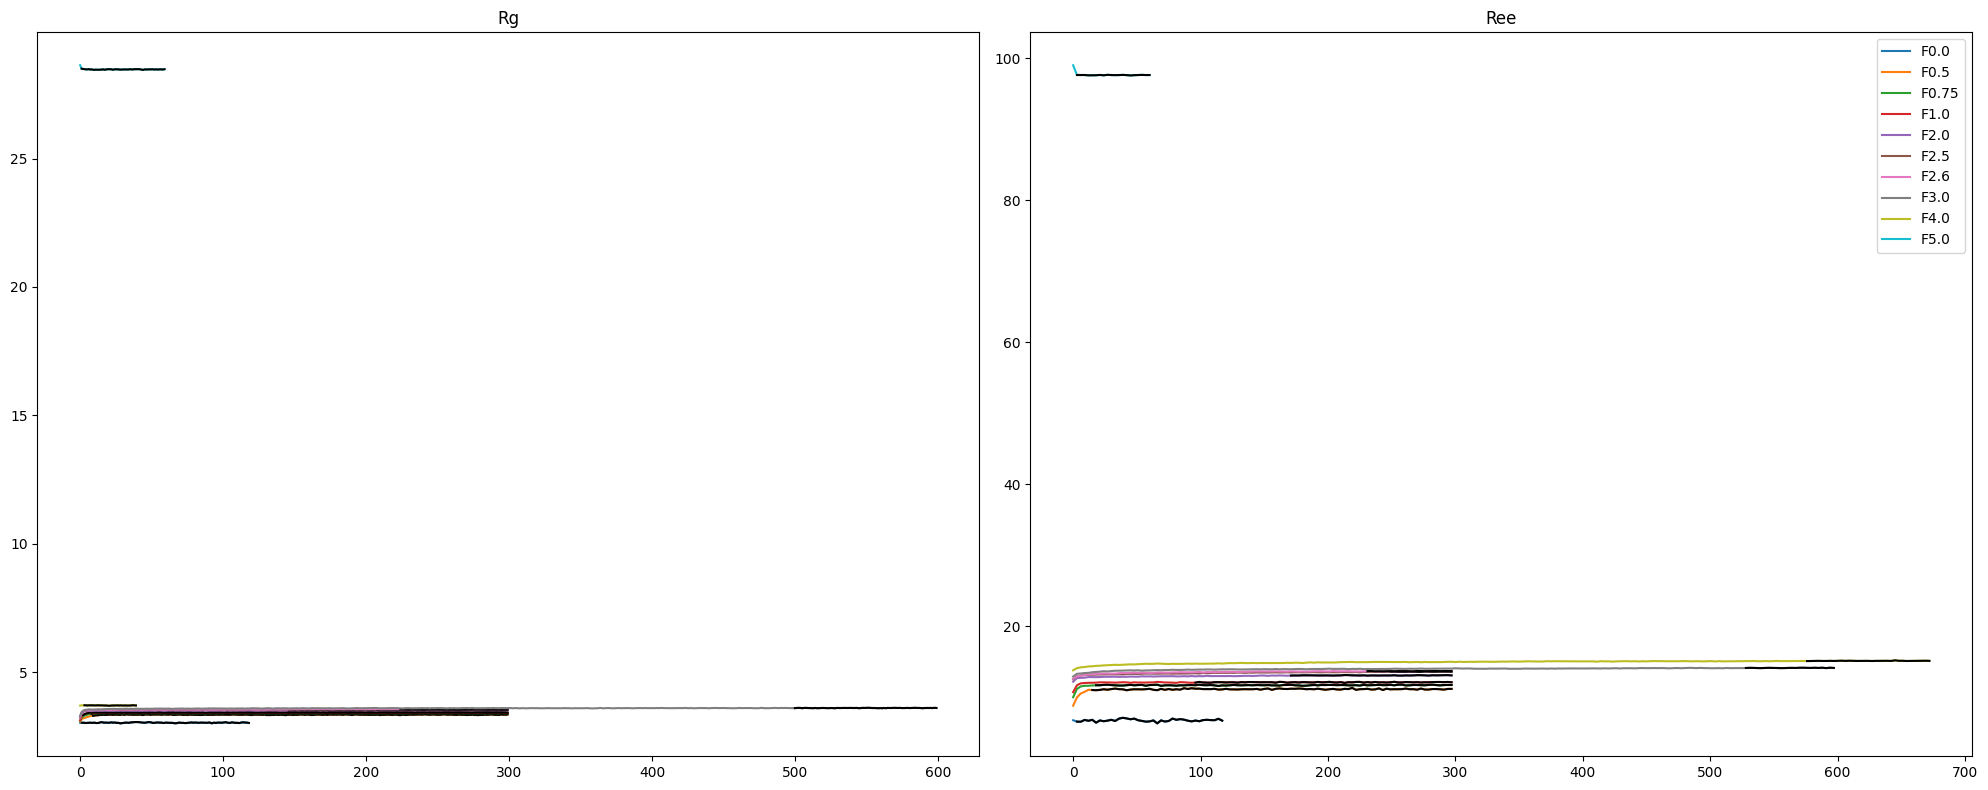

In [70]:
#T = 0.1
f = [0, 0.5, 0.75, 1, 2, 2.5, 2.6, 3, 4, 5]
t = 0.1

Rgpaths = [
    '../block10/T0.1/force0/p4/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/Hysteresis/force0.5/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/Hysteresis/force0.75/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/Hysteresis/force1/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/Hysteresis/force2/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/Hysteresis/force2.5/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/Hysteresis/force2.6/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/Hysteresis/force3/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/Hysteresis/force4/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/force5/sv.rc2.5N100T0.1p1',
]
Reepaths = [
    '../block10/T0.1/force0/p4/dump.rc2.5N100Tp1',
    '../block10/T0.1/Hysteresis/force0.5/dump',
    '../block10/T0.1/Hysteresis/force0.75/dump',
    '../block10/T0.1/Hysteresis/force1/dump',
    '../block10/T0.1/Hysteresis/force2/dump',
    '../block10/T0.1/Hysteresis/force2.5/dump',
    '../block10/T0.1/Hysteresis/force2.6/dump',
    '../block10/T0.1/Hysteresis/force3/dump',
    '../block10/T0.1/Hysteresis/force4/dump',
    '../block10/T0.1/force5/dump.rc2.5N100Tp1',
]

CGT01_H = CGT(f, t, 10, Reepaths, Rgpaths)

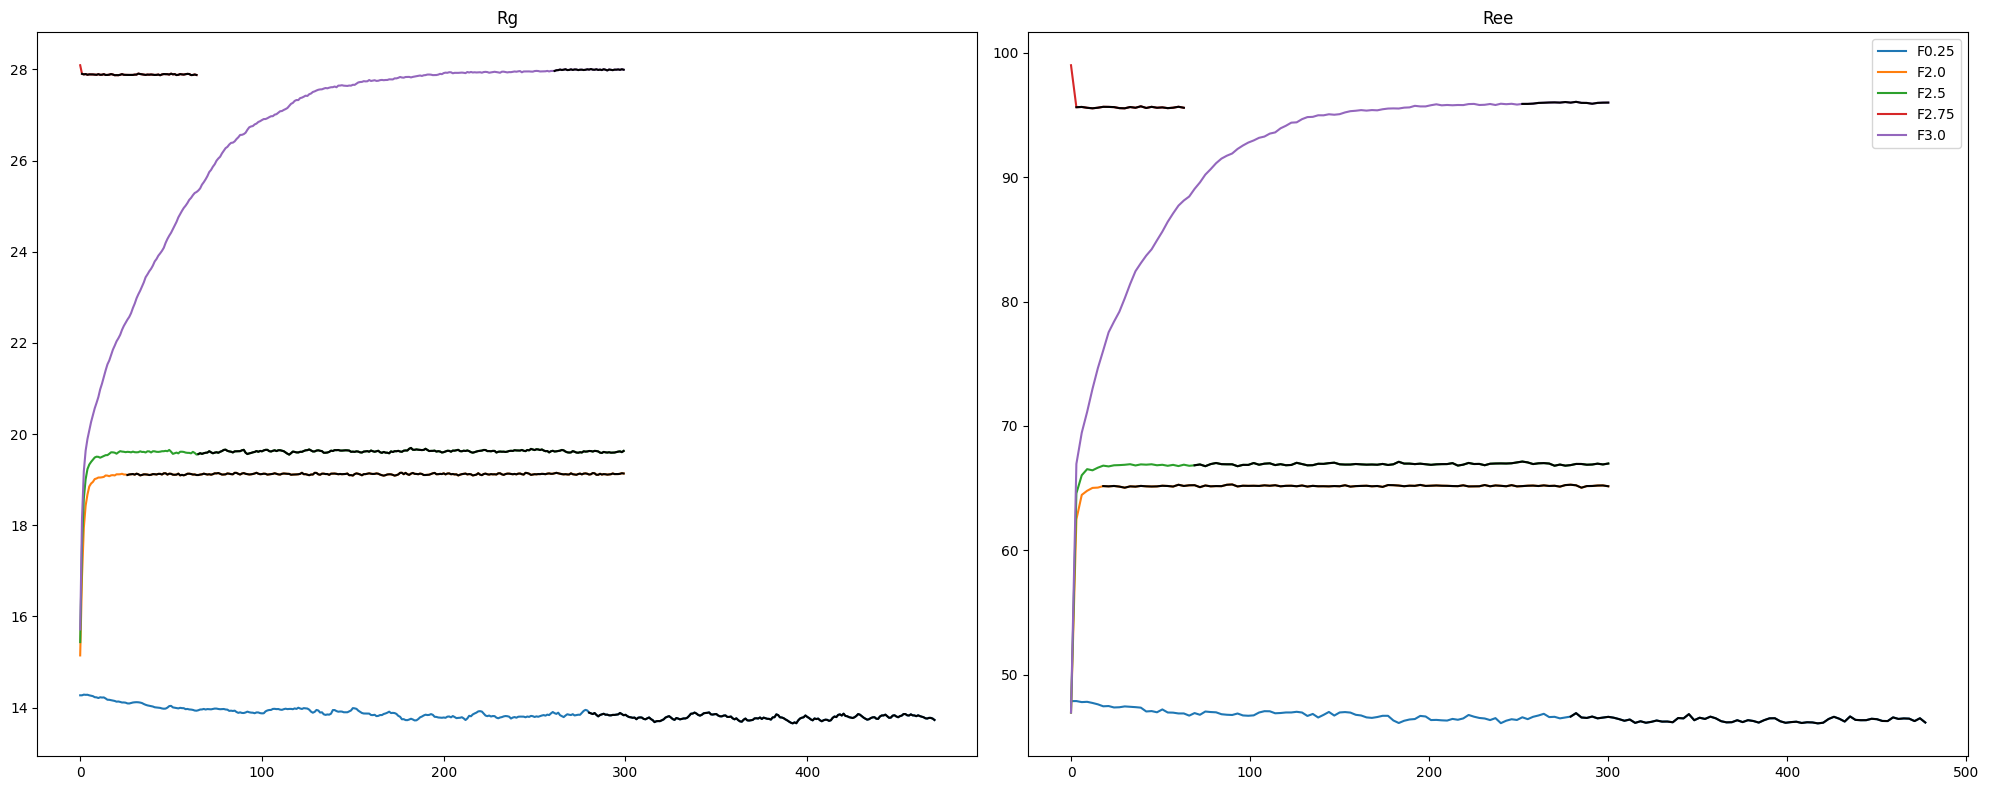

In [71]:
#T = 0.1, necklace to coil
f = [0.25, 2, 2.5, 2.75, 3]
t = 0.1

Rgpaths = [
    '../block10/T0.1/force0.25/p2/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/Hysteresis2/force2/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/Hysteresis2/force2.5/sv.rc2.5N100T0.1p1',
    '../block10/T0.1//force2.75/sv.rc2.5N100T0.1p1',
    '../block10/T0.1/Hysteresis2/force3/sv.rc2.5N100T0.1p1',
]

Reepaths = [
    '../block10/T0.1/force0.25/p2/dump.rc2.5N100Tp1',
    '../block10/T0.1/Hysteresis2/force2/dump',
    '../block10/T0.1/Hysteresis2/force2.5/dump',
    '../block10/T0.1/force2.75/dump',
    '../block10/T0.1/Hysteresis2/force3/dump',
]

CGT01_H2 = CGT(f, t, 10, Reepaths, Rgpaths)

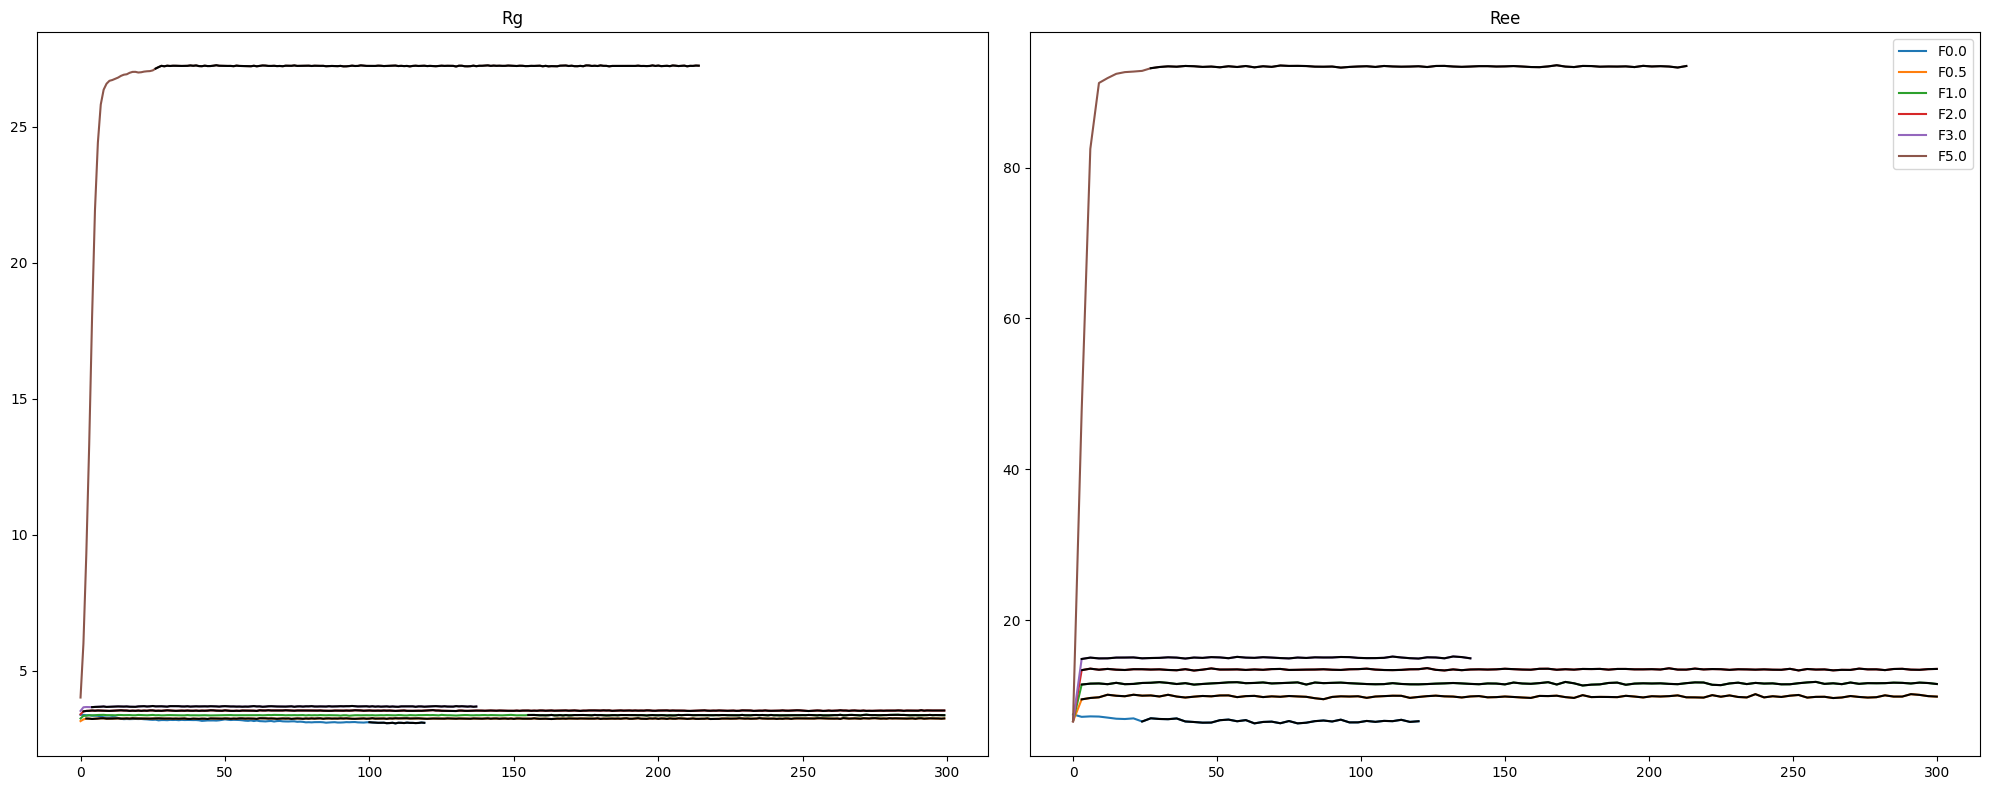

In [72]:
#T = 0.3
f = [0, 0.5, 1, 2, 3, 5]
t = 0.3

Rgpaths = [
    '../block10/T0.3/force0/p2/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/Hysteresis/force0.5/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/Hysteresis/force1/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/Hysteresis/force2/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/Hysteresis/force3/sv.rc2.5N100T0.3p1',
    '../block10/T0.3/Hysteresis/force5/sv.rc2.5N100T0.3p1',
]
Reepaths = [
    '../block10/T0.3/force0/p2/dump.rc2.5N100Tp1',
    '../block10/T0.3/Hysteresis/force0.5/dump',
    '../block10/T0.3/Hysteresis/force1/dump',
    '../block10/T0.3/Hysteresis/force2/dump',
    '../block10/T0.3/Hysteresis/force3/dump',
    '../block10/T0.3/Hysteresis/force5/dump',
]
CGT03_H = CGT(f, t, 10, Reepaths, Rgpaths)

In [73]:
filename = 'Block10_CGT_H.pkl'

with open(filename, 'wb') as file:
    pickle.dump(CGT01_H, file)
    pickle.dump(CGT01_H2, file)
    pickle.dump(CGT03_H, file)

## Block 50

#### Unloading

No equilirbium found: F2.0
No equilirbium found: F2.0
No equilirbium found: F2.2
No equilirbium found: F2.2


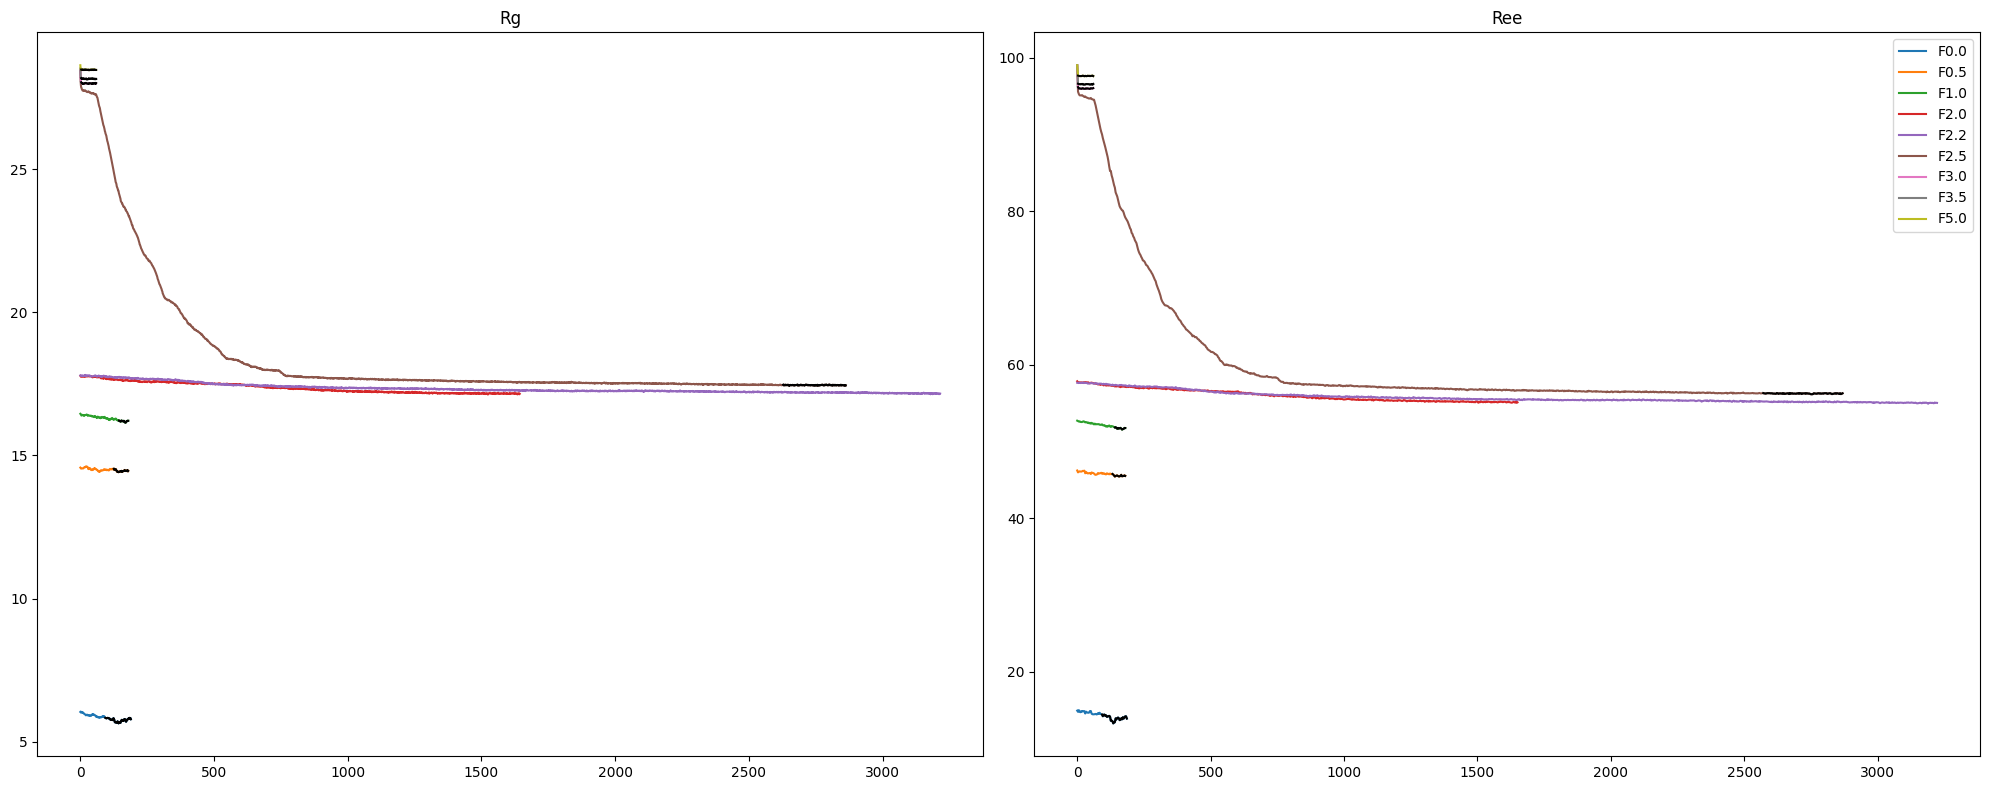

In [26]:
#T = 0.1
f = [0, 0.5, 1, 2, 2.2, 2.5, 3, 3.5, 5]
t = 0.1
Rgpaths = [
    '../block50/T0.1/force0/p5/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/force0.5/p4/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/force1/p4/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/force2/p4/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/force2.2/p4/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/force2.5/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/force3/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/force3.5/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/force5/sv.rc2.5N100T0.1p1',
]
Reepaths = [
    '../block50/T0.1/force0/p5/dump.rc2.5N100Tp1',
    '../block50/T0.1/force0.5/p4/dump.rc2.5N100Tp1',
    '../block50/T0.1/force1/p4/dump.rc2.5N100Tp1',
    '../block50/T0.1/force2/p4/dump.rc2.5N100Tp1',
    '../block50/T0.1/force2.2/p4/dump.rc2.5N100Tp1',
    '../block50/T0.1/force2.5/dump.rc2.5N100Tp1',
    '../block50/T0.1/force3/dump.rc2.5N100Tp1',
    '../block50/T0.1/force3.5/dump.rc2.5N100Tp1',
    '../block50/T0.1/force5/dump.rc2.5N100Tp1',
]

CGT01 = CGT(f, t, 50, Reepaths, Rgpaths)

No equilirbium found: F2.5
No equilirbium found: F2.5


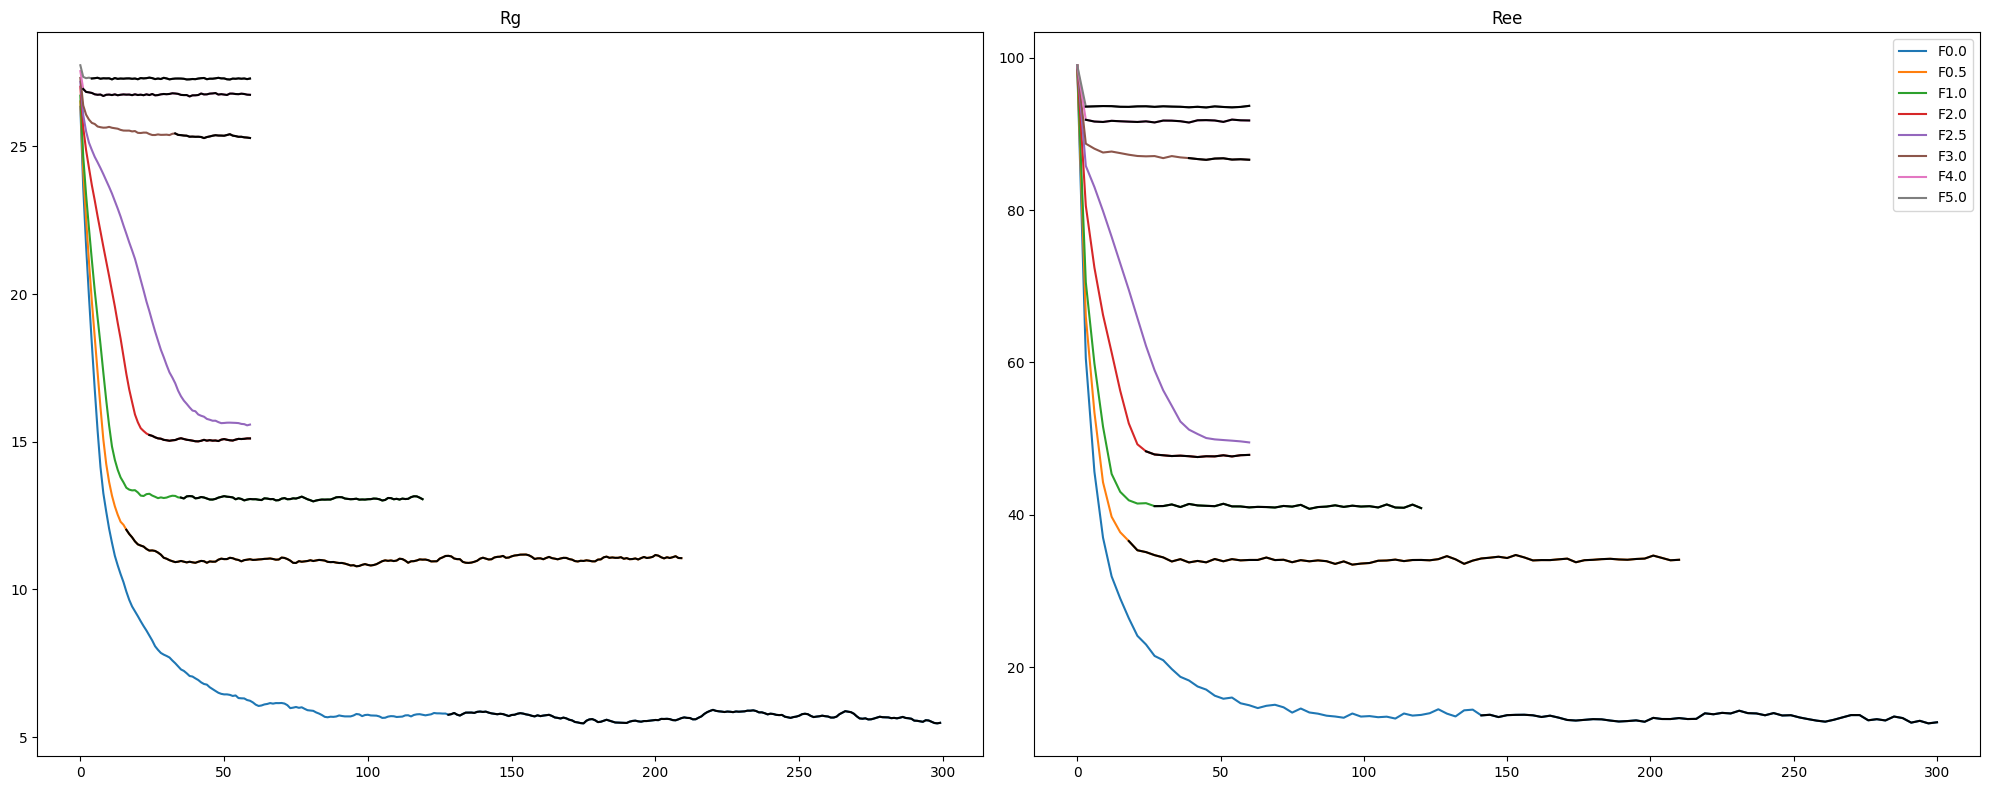

In [344]:
#T = 0.3
f = [0, 0.5, 1, 2, 2.5, 3, 4, 5]
t = 0.3

Rgpaths = [
    '../block50/T0.3/force0/sv.rc2.5N100T0.3p1',
    '../block50/T0.3/force0.5/sv.rc2.5N100T0.3p1',
    '../block50/T0.3/force1/sv.rc2.5N100T0.3p1',
    '../block50/T0.3/force2/sv.rc2.5N100T0.3p1',
    '../block50/T0.3/force2.5/sv.rc2.5N100T0.3p1',
    '../block50/T0.3/force3/sv.rc2.5N100T0.3p1',
    '../block50/T0.3/force4/sv.rc2.5N100T0.3p1',
    '../block50/T0.3/force5/sv.rc2.5N100T0.3p1',
]
Reepaths = [
    '../block50/T0.3/force0/dump.rc2.5N100Tp1',
    '../block50/T0.3/force0.5/dump.rc2.5N100Tp1',
    '../block50/T0.3/force1/dump.rc2.5N100Tp1',
    '../block50/T0.3/force2/dump.rc2.5N100Tp1',
    '../block50/T0.3/force2.5/dump.rc2.5N100Tp1',
    '../block50/T0.3/force3/dump.rc2.5N100Tp1',
    '../block50/T0.3/force4/dump.rc2.5N100Tp1',
    '../block50/T0.3/force5/dump.rc2.5N100Tp1',
]

CGT03 = CGT(f, t, 50, Reepaths, Rgpaths)

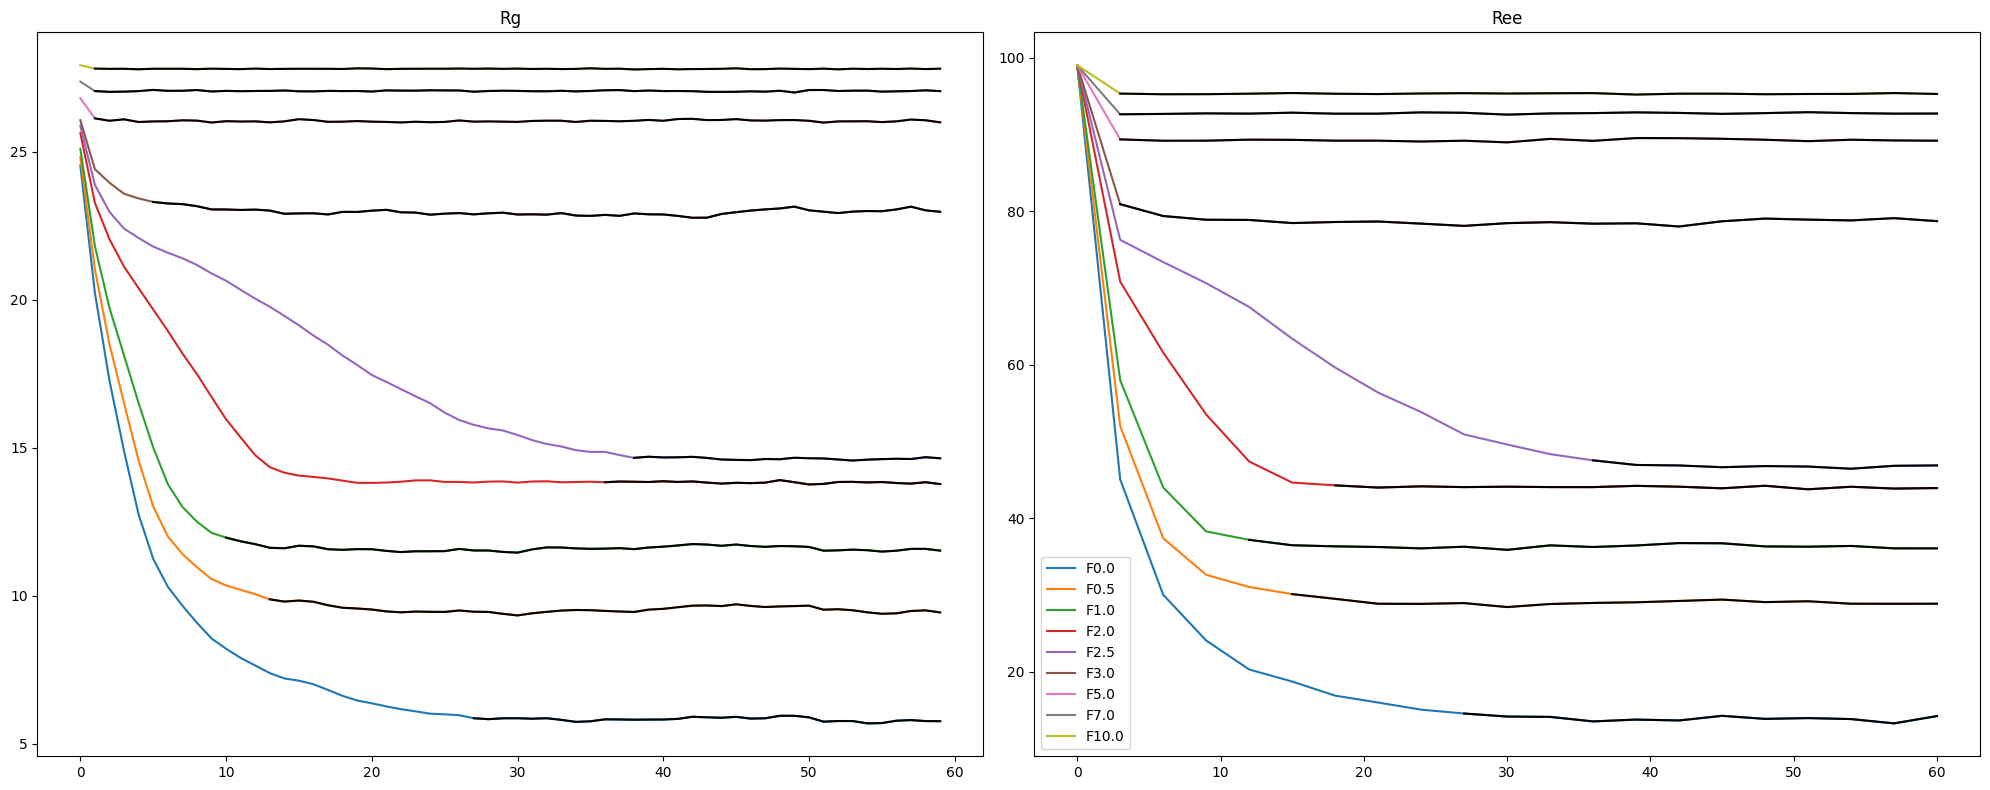

In [346]:
#T = 0.5
f = [0, 0.5, 1, 2, 2.5, 3, 5, 7, 10]
t = 0.5

Rgpaths = [
    '../block50/T0.5/force0/sv.rc2.5N100T0.5p1',
    '../block50/T0.5/force0.5/sv.rc2.5N100T0.5p1',
    '../block50/T0.5/force1/sv.rc2.5N100T0.5p1',
    '../block50/T0.5/force2/sv.rc2.5N100T0.5p1',
    '../block50/T0.5/force2.5/sv.rc2.5N100T0.5p1',
    '../block50/T0.5/force3/sv.rc2.5N100T0.5p1',
    '../block50/T0.5/force5/sv.rc2.5N100T0.5p1',
    '../block50/T0.5/force7/sv.rc2.5N100T0.5p1',
    '../block50/T0.5/force10/sv.rc2.5N100T0.5p1',
]
Reepaths = [
     '../block50/T0.5/force0/dump.rc2.5N100Tp1',
     '../block50/T0.5/force0.5/dump.rc2.5N100Tp1',
     '../block50/T0.5/force1/dump.rc2.5N100Tp1',
     '../block50/T0.5/force2/dump.rc2.5N100Tp1',
     '../block50/T0.5/force2.5/dump.rc2.5N100Tp1',
     '../block50/T0.5/force3/dump.rc2.5N100Tp1',
     '../block50/T0.5/force5/dump.rc2.5N100Tp1',
     '../block50/T0.5/force7/dump.rc2.5N100Tp1',
     '../block50/T0.5/force10/dump.rc2.5N100Tp1',
]

CGT05 = CGT(f, t, 50, Reepaths, Rgpaths)

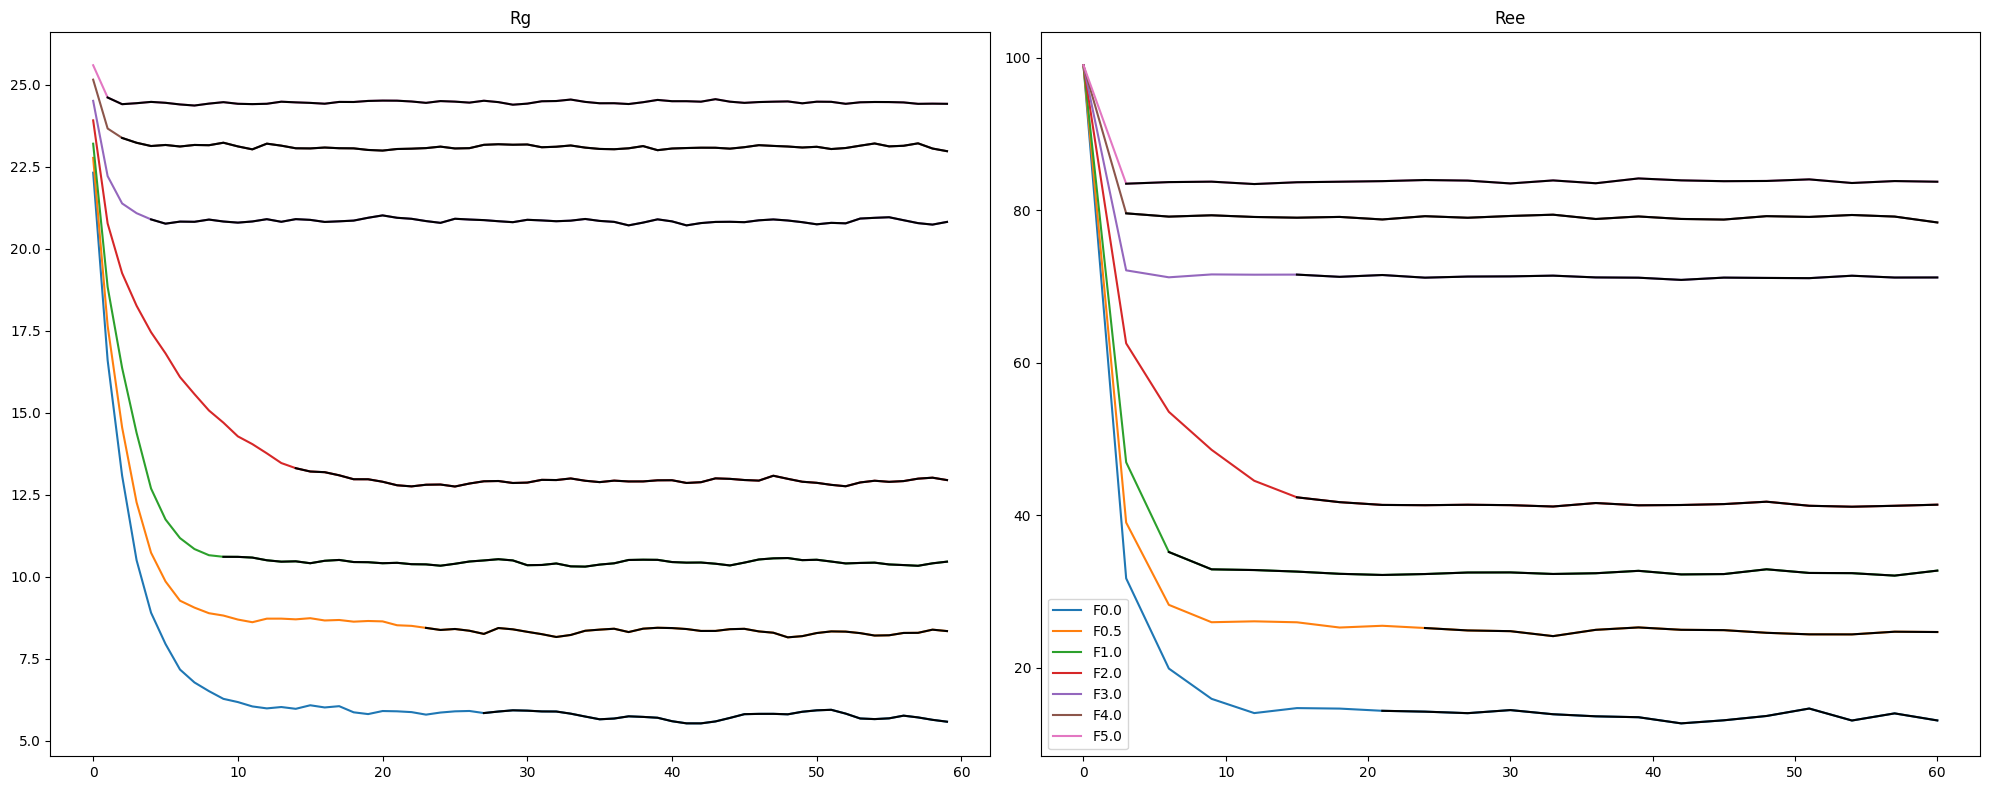

In [ ]:
#T = 0.75
f = [0, 0.5, 1, 2, 3, 4, 5]
t = 0.75
Rgpaths = [
    '../block50/T0.75/force0/sv.rc2.5N100T0.75p1',
    '../block50/T0.75/force0.5/sv.rc2.5N100T0.75p1',
    '../block50/T0.75/force1/sv.rc2.5N100T0.75p1',
    '../block50/T0.75/force2/sv.rc2.5N100T0.75p1',
    '../block50/T0.75/force3/sv.rc2.5N100T0.75p1',
    '../block50/T0.75/force4/sv.rc2.5N100T0.75p1',
    '../block50/T0.75/force5/sv.rc2.5N100T0.75p1',
]
Reepaths = [
    '../block50/T0.75/force0/dump.rc2.5N100Tp1',
    '../block50/T0.75/force0.5/dump.rc2.5N100Tp1',
    '../block50/T0.75/force1/dump.rc2.5N100Tp1',
    '../block50/T0.75/force2/dump.rc2.5N100Tp1',
    '../block50/T0.75/force3/dump.rc2.5N100Tp1',
    '../block50/T0.75/force4/dump.rc2.5N100Tp1',
    '../block50/T0.75/force5/dump.rc2.5N100Tp1',
]

CGT075 = CGT(f, t, 50, Reepaths, Rgpaths)

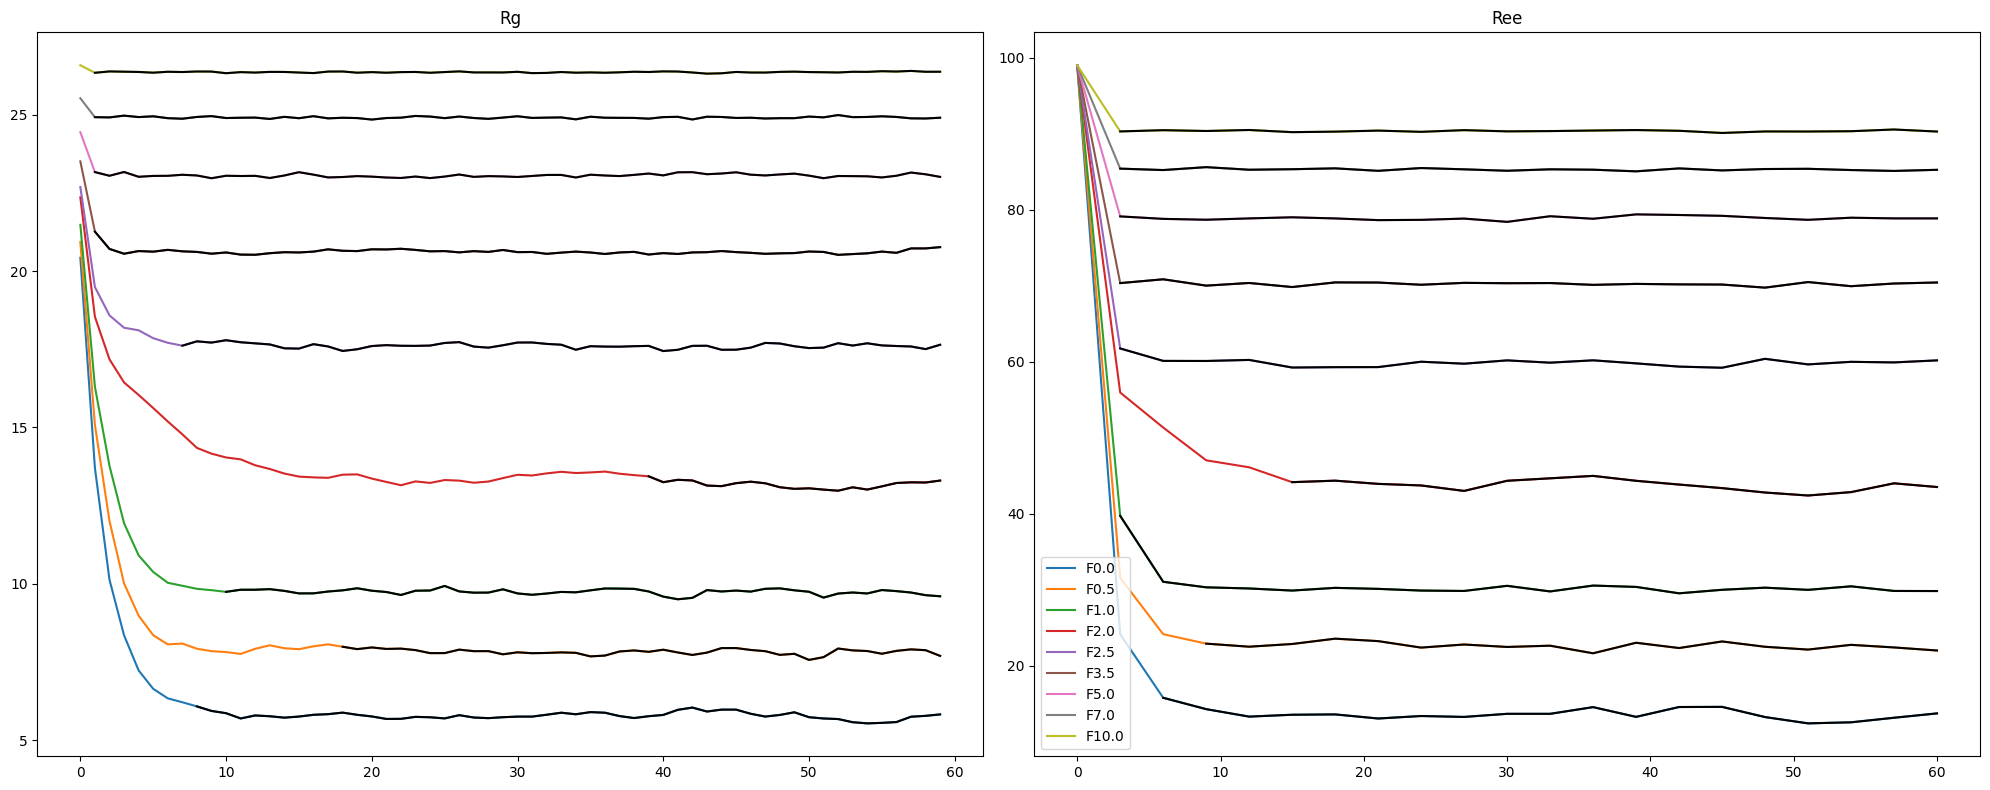

In [348]:
#T = 1
f = [0, 0.5, 1, 2, 2.5, 3.5, 5, 7, 10]
t = 1
Rgpaths = [
    '../block50/T1/force0/sv.rc2.5N100T1p1',
    '../block50/T1/force0.5/sv.rc2.5N100T1p1',
    '../block50/T1/force1/sv.rc2.5N100T1p1',
    '../block50/T1/force2/sv.rc2.5N100T1p1',
    '../block50/T1/force2.5/sv.rc2.5N100T1p1',
    '../block50/T1/force3.5/sv.rc2.5N100T1p1',
    '../block50/T1/force5/sv.rc2.5N100T1p1',
    '../block50/T1/force7/sv.rc2.5N100T1p1',
    '../block50/T1/force10/sv.rc2.5N100T1p1',
]
Reepaths = [
    '../block50/T1/force0/dump.rc2.5N100Tp1',
    '../block50/T1/force0.5/dump.rc2.5N100Tp1',
    '../block50/T1/force1/dump.rc2.5N100Tp1',
    '../block50/T1/force2/dump.rc2.5N100Tp1',
    '../block50/T1/force2.5/dump.rc2.5N100Tp1',
    '../block50/T1/force3.5/dump.rc2.5N100Tp1',
    '../block50/T1/force5/dump.rc2.5N100Tp1',
    '../block50/T1/force7/dump.rc2.5N100Tp1',
    '../block50/T1/force10/dump.rc2.5N100Tp1',
]


CGT1 = CGT(f, t, 50, Reepaths, Rgpaths)

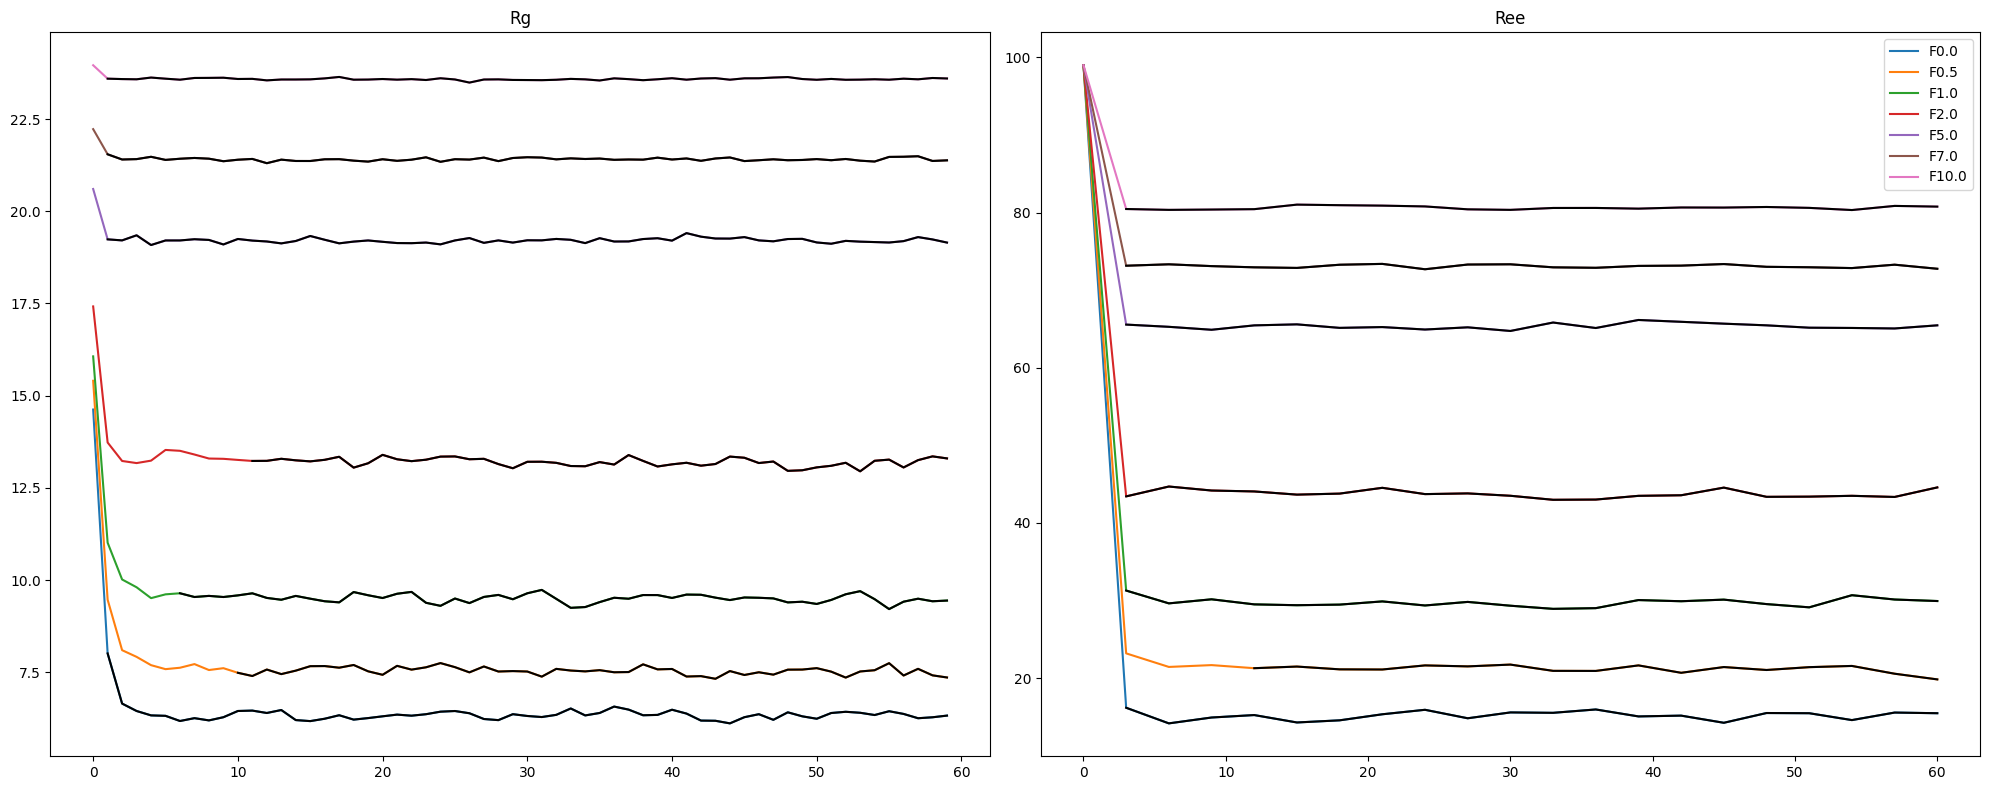

In [349]:
#T = 2
f = [0, 0.5, 1, 2, 5, 7, 10]
t = 2

Rgpaths = [
    '../block50/T2/force0/sv.rc2.5N100T2p1',
    '../block50/T2/force0.5/sv.rc2.5N100T2p1',
    '../block50/T2/force1/sv.rc2.5N100T2p1',
    '../block50/T2/force2/sv.rc2.5N100T2p1',
    '../block50/T2/force5/sv.rc2.5N100T2p1',
    '../block50/T2/force7/sv.rc2.5N100T2p1',
    '../block50/T2/force10/sv.rc2.5N100T2p1',
]
Reepaths = [
    '../block50/T2/force0/dump.rc2.5N100Tp1',
    '../block50/T2/force0.5/dump.rc2.5N100Tp1',
    '../block50/T2/force1/dump.rc2.5N100Tp1',
    '../block50/T2/force2/dump.rc2.5N100Tp1',
    '../block50/T2/force5/dump.rc2.5N100Tp1',
    '../block50/T2/force7/dump.rc2.5N100Tp1',
    '../block50/T2/force10/dump.rc2.5N100Tp1',
]

CGT2 = CGT(f, t, 50, Reepaths, Rgpaths)

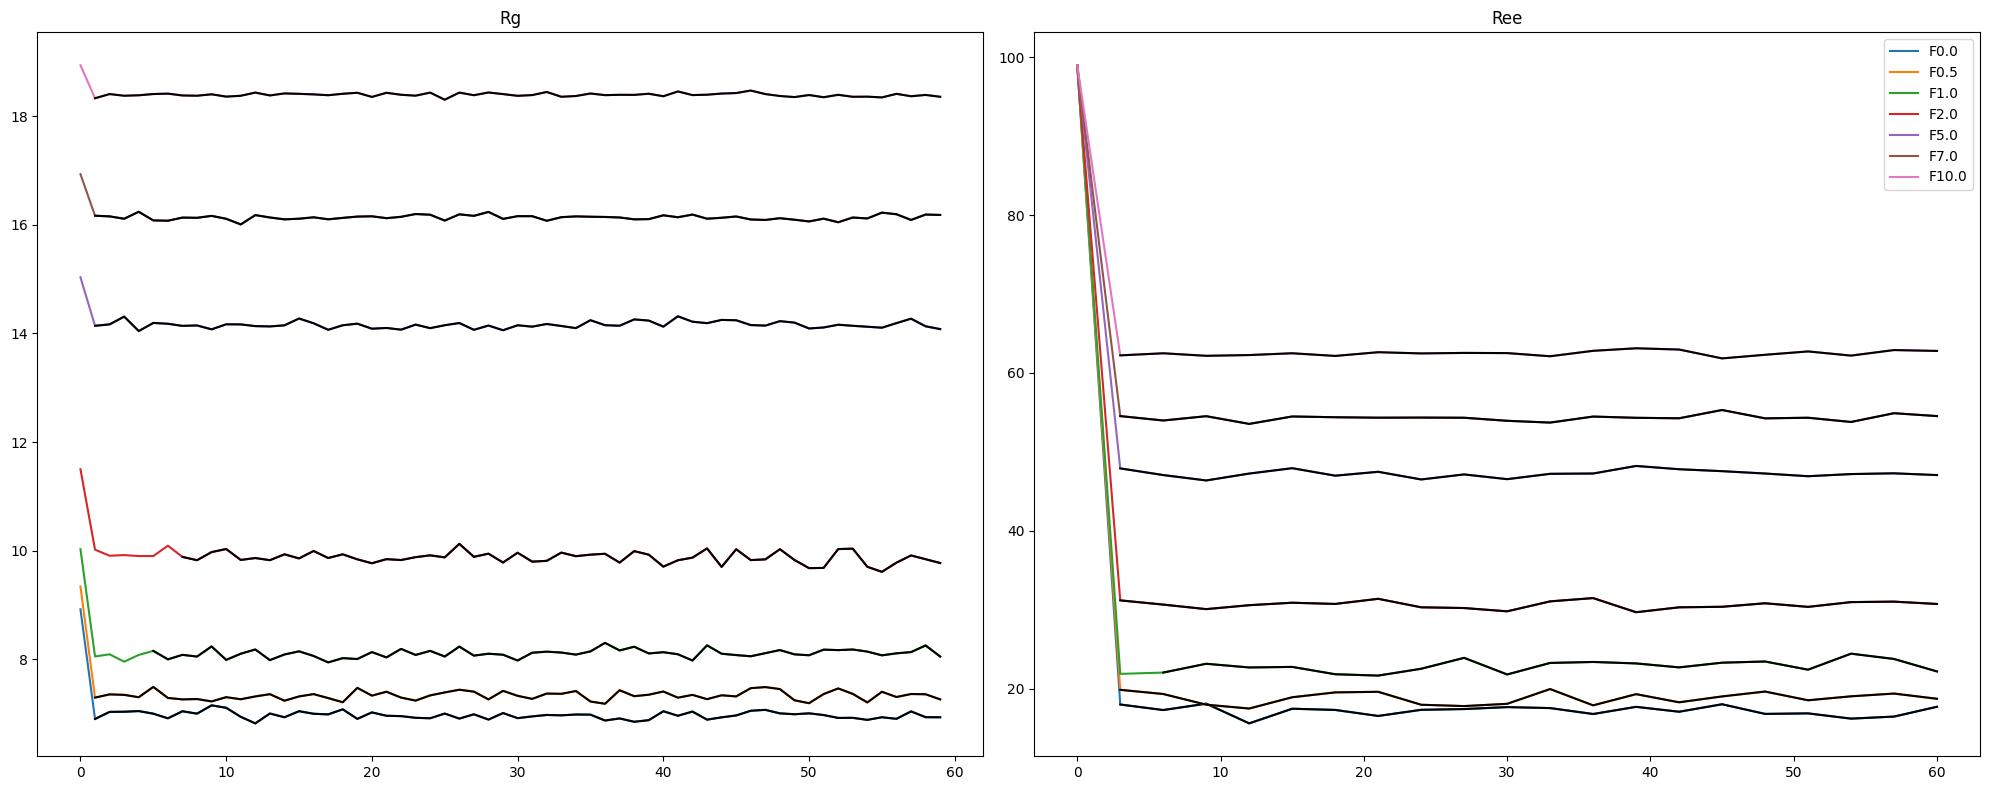

In [350]:
#T = 5
f = [0, 0.5, 1, 2, 5, 7, 10]
t = 5
Rgpaths = [
    '../block50/T5/force0/sv.rc2.5N100T5p1',
    '../block50/T5/force0.5/sv.rc2.5N100T5p1',
    '../block50/T5/force1/sv.rc2.5N100T5p1',
    '../block50/T5/force2/sv.rc2.5N100T5p1',
    '../block50/T5/force5/sv.rc2.5N100T5p1',
    '../block50/T5/force7/sv.rc2.5N100T5p1',
    '../block50/T5/force10/sv.rc2.5N100T5p1',
]
Reepaths = [
     '../block50/T5/force0/dump.rc2.5N100Tp1',
     '../block50/T5/force0.5/dump.rc2.5N100Tp1',
     '../block50/T5/force1/dump.rc2.5N100Tp1',
     '../block50/T5/force2/dump.rc2.5N100Tp1',
     '../block50/T5/force5/dump.rc2.5N100Tp1',
     '../block50/T5/force7/dump.rc2.5N100Tp1',
     '../block50/T5/force10/dump.rc2.5N100Tp1',
]

CGT5 = CGT(f, t, 50, Reepaths, Rgpaths)

In [ ]:
filename = 'Block50_CGT.pkl'

with open(filename, 'wb') as file:
    pickle.dump(CGT01, file)
    pickle.dump(CGT03, file)
    pickle.dump(CGT05, file)
    pickle.dump(CGT075, file)
    pickle.dump(CGT1, file)
    pickle.dump(CGT2, file)
    pickle.dump(CGT5, file)

#### Loading

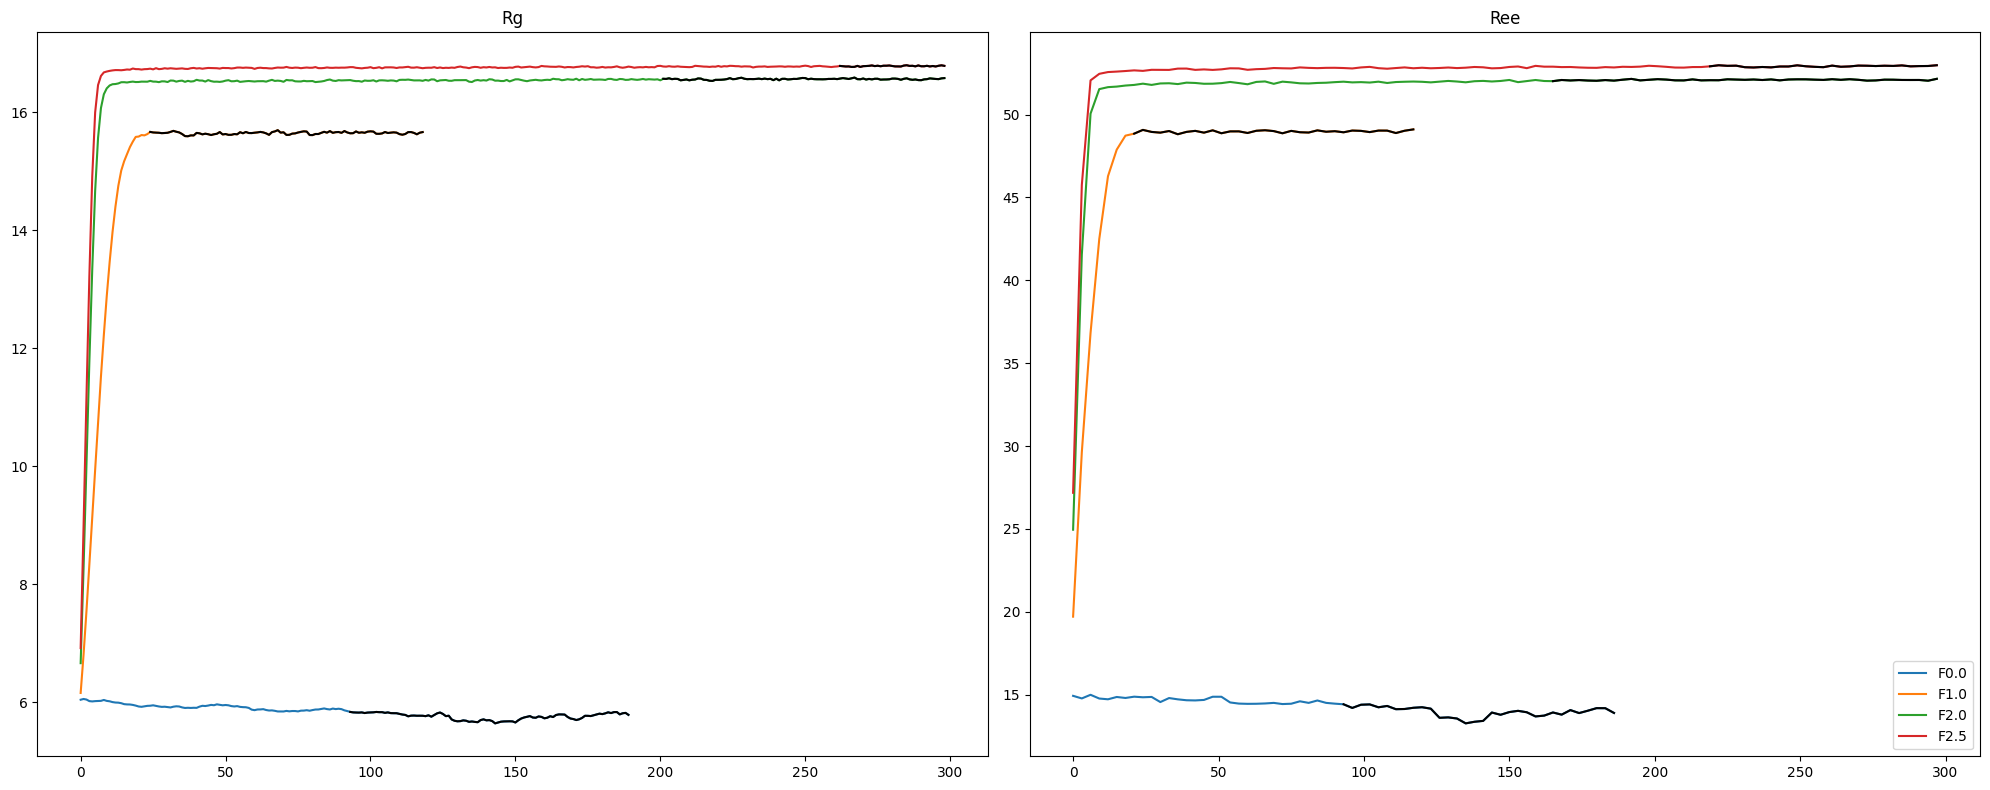

In [29]:
#T = 0.1
f = [0, 1, 2, 2.5]
t = 0.1
Rgpaths = [
    '../block50/T0.1/force0/p5/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/Hysteresis/force1/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/Hysteresis/force2/sv.rc2.5N100T0.1p1',
    '../block50/T0.1/Hysteresis/force2.5/sv.rc2.5N100T0.1p1',
]
Reepaths = [
    '../block50/T0.1/force0/p5/dump.rc2.5N100Tp1',
    '../block50/T0.1/Hysteresis/force1/dump.rc2.5N100Tp1',
    '../block50/T0.1/Hysteresis/force2/dump.rc2.5N100Tp1',
    '../block50/T0.1/Hysteresis/force2.5/dump.rc2.5N100Tp1',
]

CGT01_H = CGT(f, t, 50, Reepaths, Rgpaths)

In [30]:
filename = 'Block50_CGT_H.pkl'

with open(filename, 'wb') as file:
    pickle.dump(CGT01_H, file)